## Autores: Josep Pérez Segura, Raul Rodríguez López Rey
# Tarea B3-T1


## 1. Importación de datos

Descargamos datos históricos de **un criptoactivo** (Bitcoin) desde la API pública de Binance:

| # | Símbolo | Descripción |
|---|---------|-------------|
| 1 | BTCUSDT | Bitcoin |

- **Intervalo**: velas de 5 minutos
- **Periodo**: últimos ~5 años (marzo 2021 – marzo 2026)
- Los datos se cachean en CSV para evitar re-descargas.

**Limpieza de huecos temporales:** El activo presenta un hueco de 16 velas (85 min) el 2023-03-24 entre las 12:35 y las 14:00 UTC, correspondiente a una ventana de mantenimiento programado de Binance en la que el exchange no generó velas. Para mantener la continuidad de la serie temporal se rellenan estas velas ausentes mediante *forward-fill*: se replica el último precio conocido (open, high, low, close) y se asignan volumen y número de trades a cero, ya que no hubo actividad real.

In [67]:
%pip install requests pandas numpy matplotlib tqdm --quiet

Note: you may need to restart the kernel to use updated packages.


In [68]:
import datetime
import time
from pathlib import Path

import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

pd.set_option("display.max_columns", None)

In [69]:
# --- Configuración ---
SYMBOLS = [
    "BTCUSDT",   # Bitcoin
]

INTERVAL = "5m"
BASE_URL = "https://api.binance.com/api/v3/klines"

START_DATE = datetime.datetime(2021, 3, 17)
END_DATE = datetime.datetime(2026, 3, 17)
START_MS = int(START_DATE.timestamp() * 1000)
END_MS = int(END_DATE.timestamp() * 1000)

LIMIT = 1000
SLEEP_BETWEEN = 0.05

DATA_DIR = Path("data")

print(f"Periodo: {START_DATE.date()} -> {END_DATE.date()}")
print(f"Intervalo: {INTERVAL}")
print(f"Activos: {len(SYMBOLS)}")
for s in SYMBOLS:
    print(f"  - {s}")

Periodo: 2021-03-17 -> 2026-03-17
Intervalo: 5m
Activos: 1
  - BTCUSDT


In [70]:
def fetch_klines(symbol, interval, start_ms, end_ms, limit=1000):
    """Descarga velas de Binance con paginación automática."""
    session = requests.Session()
    all_klines = []
    current_ms = start_ms

    # Estimar número de requests para la barra de progreso
    interval_ms = 5 * 60 * 1000  # 5 minutos en ms
    estimated_requests = (end_ms - start_ms) // (limit * interval_ms) + 1

    pbar = tqdm(total=estimated_requests, desc="Descargando velas")

    while current_ms < end_ms:
        params = {
            "symbol": symbol,
            "interval": interval,
            "startTime": current_ms,
            "endTime": end_ms,
            "limit": limit,
        }

        resp = session.get(BASE_URL, params=params)

        # Manejo de rate limiting
        if resp.status_code in (429, 418):
            retry_after = int(resp.headers.get("Retry-After", 5))
            print(f"Rate limited. Esperando {retry_after}s...")
            time.sleep(retry_after)
            continue

        resp.raise_for_status()
        data = resp.json()

        if not data:
            break

        all_klines.extend(data)

        # Avanzar: close_time del último registro + 1 ms
        current_ms = data[-1][6] + 1
        pbar.update(1)

        time.sleep(SLEEP_BETWEEN)

    pbar.close()
    print(f"Total velas descargadas: {len(all_klines):,}")
    return all_klines

In [ ]:
# --- Descarga / carga de todos los activos ---
DATA_DIR.mkdir(exist_ok=True)

columns = [
    "open_time", "open", "high", "low", "close", "volume",
    "close_time", "quote_volume", "num_trades",
    "taker_buy_base_vol", "taker_buy_quote_vol", "ignore",
]
numeric_cols = ["open", "high", "low", "close", "volume",
                "quote_volume", "taker_buy_base_vol", "taker_buy_quote_vol"]

dfs = {}  # diccionario {symbol: DataFrame}

for symbol in SYMBOLS:
    csv_path = DATA_DIR / f"{symbol}_{INTERVAL}_5y.csv"

    if csv_path.exists():
        print(f"[{symbol}] Cargando desde cache: {csv_path}")
        dfs[symbol] = pd.read_csv(csv_path, parse_dates=["open_time", "close_time"])
    else:
        print(f"[{symbol}] Descargando de Binance API...")
        raw = fetch_klines(symbol, INTERVAL, START_MS, END_MS, LIMIT)

        tmp = pd.DataFrame(raw, columns=columns)
        tmp[numeric_cols] = tmp[numeric_cols].astype(float)
        tmp["num_trades"] = tmp["num_trades"].astype(int)
        tmp["open_time"] = pd.to_datetime(tmp["open_time"], unit="ms")
        tmp["close_time"] = pd.to_datetime(tmp["close_time"], unit="ms")
        tmp.drop(columns=["ignore"], inplace=True)

        tmp.drop_duplicates(subset=["open_time"], inplace=True)
        tmp.sort_values("open_time", inplace=True)
        tmp.reset_index(drop=True, inplace=True)

        tmp = tmp[(tmp["open_time"] >= str(START_DATE)) &
                  (tmp["open_time"] < str(END_DATE))]
        tmp.reset_index(drop=True, inplace=True)

        tmp.to_csv(csv_path, index=False)
        size_mb = csv_path.stat().st_size / 1e6
        print(f"  -> Guardado: {csv_path} ({len(tmp):,} filas, {size_mb:.1f} MB)")

        dfs[symbol] = tmp

# df principal = BTCUSDT
df = dfs["BTCUSDT"]

print(f"\n{'='*60}")
print(f"Resumen de descarga:")
for sym, d in dfs.items():
    print(f"  {sym:10s} -> {d.shape[0]:>10,} filas | {d['open_time'].min().date()} - {d['open_time'].max().date()}")
print(f"{'='*60}")

[BTCUSDT] Cargando desde cache: data\BTCUSDT_5m_5y.csv

Resumen de descarga:
  BTCUSDT    ->    525,697 filas | 2021-03-17 - 2026-03-16


In [72]:
# --- Forward-fill de huecos temporales (16 velas ausentes por mantenimiento de Binance) ---
for sym in dfs:
    d = dfs[sym].set_index("open_time")
    full_idx = pd.date_range(d.index.min(), d.index.max(), freq="5min", name="open_time")
    d = d.reindex(full_idx)

    # Precios: forward-fill (último precio conocido)
    price_cols = ["open", "high", "low", "close"]
    d[price_cols] = d[price_cols].ffill()

    # close_time: recalcular como open_time + 5min - 1ms
    d["close_time"] = d.index + pd.Timedelta(minutes=5) - pd.Timedelta(milliseconds=1)

    # Volumen y trades: 0 en velas sintéticas (no hubo actividad)
    vol_cols = ["volume", "quote_volume", "taker_buy_base_vol", "taker_buy_quote_vol"]
    d[vol_cols] = d[vol_cols].fillna(0.0)
    d["num_trades"] = d["num_trades"].fillna(0).astype(int)

    d = d.reset_index()
    dfs[sym] = d

df = dfs["BTCUSDT"]

print(f"Forward-fill completado. Verificación de huecos restantes:")
for sym, d in dfs.items():
    gaps = d["open_time"].diff().dt.total_seconds().dropna()
    n_gaps = (gaps != 300).sum()
    print(f"  {sym:10s} -> {d.shape[0]:>10,} filas | huecos: {n_gaps}")

Forward-fill completado. Verificación de huecos restantes:
  BTCUSDT    ->    525,877 filas | huecos: 0


In [73]:
# --- Verificación y exploración ---
for sym, d in dfs.items():
    print(f"\n{'─'*50}")
    print(f"  {sym}")
    print(f"  Periodo: {d['open_time'].min()} -> {d['open_time'].max()}")
    print(f"  Memoria: {d.memory_usage(deep=True).sum() / 1e6:.1f} MB")
    print(f"  Shape:   {d.shape}")

    deltas = d["open_time"].diff().dt.total_seconds().dropna()
    gaps = deltas[deltas != 300]
    print(f"  Huecos temporales (intervalos != 5 min): {len(gaps)} de {len(deltas)}")

print(f"\n{'─'*50}")
print("\nDetalle BTCUSDT (df principal):")
display(df.describe())



──────────────────────────────────────────────────
  BTCUSDT
  Periodo: 2021-03-17 00:00:00 -> 2026-03-16 23:00:00
  Memoria: 46.3 MB
  Shape:   (525877, 11)
  Huecos temporales (intervalos != 5 min): 0 de 525876

──────────────────────────────────────────────────

Detalle BTCUSDT (df principal):


,open_time,open,high,low,close,volume,close_time,quote_volume,num_trades,taker_buy_base_vol,taker_buy_quote_vol
count,525877,525877.000000,525877.000000,525877.000000,525877.000000,525877.000000,525877,5.258770e+05,525877.000000,525877.000000,5.258770e+05
mean,2023-09-15 23:30:00.000001536,55842.228947,55897.955752,55785.697099,55842.282868,248.755366,2023-09-15 23:34:59.998998784,8.982756e+06,10275.182775,123.097557,4.428224e+06
min,2021-03-17 00:00:00,15590.570000,15633.310000,15476.000000,15593.580000,0.000000,2021-03-17 00:04:59.999000,0.000000e+00,0.000000,0.000000,0.000000e+00
25%,2022-06-16 11:45:00,29416.810000,29429.700000,29402.430000,29416.820000,48.463249,2022-06-16 11:49:59.999000064,2.733048e+06,3122.000000,22.169650,1.253306e+06
50%,2023-09-15 23:30:00,48348.660000,48418.190000,48283.500000,48348.060000,101.498290,2023-09-15 23:34:59.999000064,5.319207e+06,5890.000000,49.335550,2.568190e+06
75%,2024-12-15 11:15:00,73446.450000,73545.170000,73339.540000,73446.770000,246.833540,2024-12-15 11:19:59.999000064,1.058998e+07,12880.000000,122.895340,5.245555e+06
max,2026-03-16 23:00:00,126011.180000,126199.630000,125868.130000,126011.180000,15659.934840,2026-03-16 23:04:59.999000,5.588519e+08,711259.000000,8884.511430,2.663202e+08
std,NaN,29750.428274,29769.739500,29730.507647,29750.432163,450.694440,NaN,1.214962e+07,12180.433283,225.767761,6.165944e+06


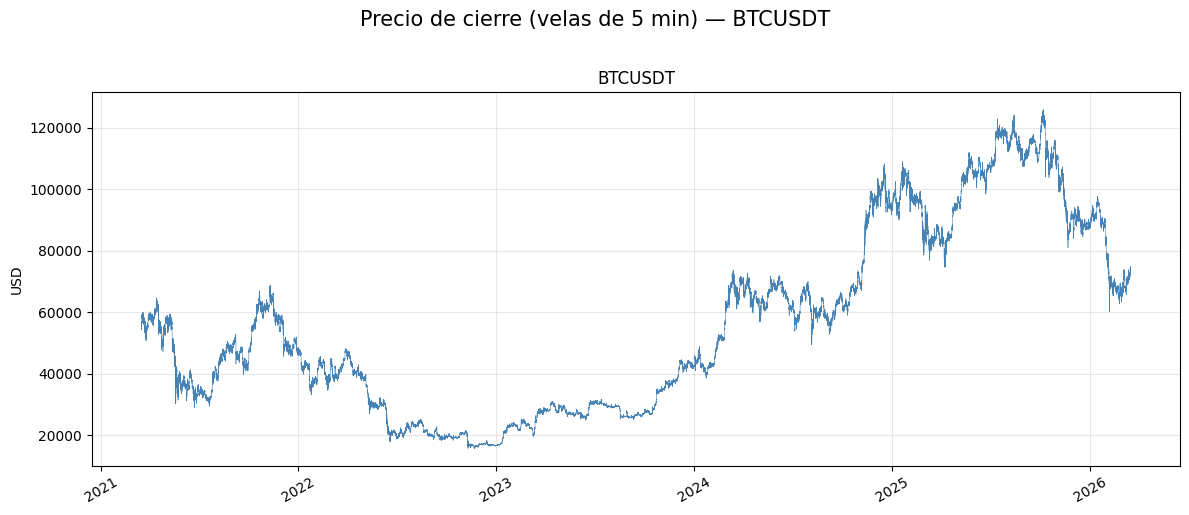

In [74]:
# --- Evolución del precio del criptoactivo ---
fig, ax = plt.subplots(figsize=(12, 5))

d = dfs["BTCUSDT"]
ax.plot(d["open_time"], d["close"], linewidth=0.4, color="steelblue")
ax.set_title("BTCUSDT", fontsize=12)
ax.set_ylabel("USD")
ax.grid(True, alpha=0.3)
ax.ticklabel_format(style="plain", axis="y")
ax.tick_params(axis="x", rotation=30)

fig.suptitle("Precio de cierre (velas de 5 min) — BTCUSDT", fontsize=15, y=1.02)
fig.tight_layout()
plt.show()

## 2. Barras alternativas: Dollar Bars, Volume Bars y Tick Bars

Las barras basadas en tiempo (time bars) presentan propiedades estadísticas indeseables: autocorrelación, heterocedasticidad y distribuciones no normales. Lopez de Prado (2018, Cap. 2) propone muestrear los datos usando **barras alternativas** que se cierran al alcanzar un umbral acumulado:

- **Tick Bars**: se cierra una barra cada N operaciones (trades). Muestrean según la actividad del mercado.
- **Volume Bars**: se cierra una barra cada V unidades de volumen (BTC). Normalizan la información por volumen negociado.
- **Dollar Bars**: se cierra una barra cada D dólares negociados (quote volume en USDT). Son las más robustas según MLdP, ya que normalizan por valor económico real.

Al usar velas de 5 min como proxy, cada vela aporta: `num_trades` (ticks), `volume` (BTC), y `quote_volume` (USDT). Acumulamos estos valores y generamos una nueva barra OHLCV cada vez que se supera el umbral.

Compararemos **3 umbrales distintos** para cada tipo de barra para ilustrar el efecto del parámetro.

In [75]:
def make_bars(df, metric_col, threshold):
    """
    Genera barras alternativas agrupando filas hasta que la suma acumulada
    de `metric_col` supera `threshold`.

    Parámetros:
        df: DataFrame con columnas open_time, open, high, low, close, volume,
            quote_volume, num_trades y la columna `metric_col`.
        metric_col: columna a acumular ('num_trades', 'volume', 'quote_volume').
        threshold: valor umbral para cerrar cada barra.

    Retorna:
        DataFrame con barras OHLCV + timestamp.
    """
    bars = []
    cum_metric = 0.0
    open_price = df.iloc[0]["open"]
    high_price = -np.inf
    low_price = np.inf
    cum_volume = 0.0
    cum_quote_volume = 0.0
    cum_trades = 0
    bar_start = df.iloc[0]["open_time"]

    for _, row in df.iterrows():
        high_price = max(high_price, row["high"])
        low_price = min(low_price, row["low"])
        cum_volume += row["volume"]
        cum_quote_volume += row["quote_volume"]
        cum_trades += row["num_trades"]
        cum_metric += row[metric_col]

        if cum_metric >= threshold:
            bars.append({
                "open_time": bar_start,
                "close_time": row["close_time"],
                "open": open_price,
                "high": high_price,
                "low": low_price,
                "close": row["close"],
                "volume": cum_volume,
                "quote_volume": cum_quote_volume,
                "num_trades": cum_trades,
            })
            # Reset
            cum_metric = 0.0
            cum_volume = 0.0
            cum_quote_volume = 0.0
            cum_trades = 0
            high_price = -np.inf
            low_price = np.inf
            open_price = row["close"]
            bar_start = row["close_time"]

    return pd.DataFrame(bars)

In [76]:
# --- Calcular estadísticas para elegir umbrales razonables ---
print("Estadísticas por vela de 5 min:")
print(f"  num_trades  -> media: {df['num_trades'].mean():,.0f}, mediana: {df['num_trades'].median():,.0f}")
print(f"  volume (BTC)-> media: {df['volume'].mean():,.1f}, mediana: {df['volume'].median():,.1f}")
print(f"  quote_vol ($)-> media: {df['quote_volume'].mean():,.0f}, mediana: {df['quote_volume'].median():,.0f}")

# Umbrales: elegidos para generar ~5K, ~15K y ~50K barras aprox.
total_trades = df["num_trades"].sum()
total_volume = df["volume"].sum()
total_dollar = df["quote_volume"].sum()

tick_thresholds = [
    int(total_trades / 50_000),
    int(total_trades / 15_000),
    int(total_trades / 5_000),
]
volume_thresholds = [
    round(total_volume / 50_000, 0),
    round(total_volume / 15_000, 0),
    round(total_volume / 5_000, 0),
]
dollar_thresholds = [
    round(total_dollar / 50_000, -3),
    round(total_dollar / 15_000, -3),
    round(total_dollar / 5_000, -3),
]

print(f"\nUmbrales Tick Bars:   {tick_thresholds} trades")
print(f"Umbrales Volume Bars: {volume_thresholds} BTC")
print(f"Umbrales Dollar Bars: {dollar_thresholds} USDT")

Estadísticas por vela de 5 min:
  num_trades  -> media: 10,275, mediana: 5,890
  volume (BTC)-> media: 248.8, mediana: 101.5
  quote_vol ($)-> media: 8,982,756, mediana: 5,319,207

Umbrales Tick Bars:   [108069, 360232, 1080696] trades
Umbrales Volume Bars: [np.float64(2616.0), np.float64(8721.0), np.float64(26163.0)] BTC
Umbrales Dollar Bars: [np.float64(94476000.0), np.float64(314922000.0), np.float64(944765000.0)] USDT


Estas estadísticas nos dan una referencia para elegir los umbrales. La idea es: una barra se cierra cuando la suma acumulada de la métrica (trades, volumen o USD) supera un umbral. Si el umbral es bajo, se generan muchas barras pequeñas; si es alto, pocas barras pero con más información cada una.

In [77]:
# --- Generar las barras alternativas ---
print("Generando barras... (puede tardar unos segundos por cada umbral)\n")

bar_results = {}

for label, col, thresholds in [
    ("Tick Bars", "num_trades", tick_thresholds),
    ("Volume Bars", "volume", volume_thresholds),
    ("Dollar Bars", "quote_volume", dollar_thresholds),
]:
    bar_results[label] = {}
    for th in thresholds:
        bars_df = make_bars(df, col, th)
        bar_results[label][th] = bars_df
        print(f"  {label} (umbral={th:,.0f}): {len(bars_df):,} barras")
    print()

Generando barras... (puede tardar unos segundos por cada umbral)

  Tick Bars (umbral=108,069): 45,181 barras
  Tick Bars (umbral=360,232): 14,512 barras
  Tick Bars (umbral=1,080,696): 4,944 barras

  Volume Bars (umbral=2,616): 42,713 barras
  Volume Bars (umbral=8,721): 14,192 barras
  Volume Bars (umbral=26,163): 4,898 barras

  Dollar Bars (umbral=94,476,000): 44,604 barras
  Dollar Bars (umbral=314,922,000): 14,438 barras
  Dollar Bars (umbral=944,765,000): 4,934 barras



Probamos 3 umbrales (bajo, medio, alto) por tipo de barra. El número de barras es inversamente proporcional al umbral: $N \approx \sum x_t \,/\, \theta$. El objetivo es encontrar el punto donde los retornos $r_j = \ln(C_j / C_{j-1})$ se comportan lo más parecido posible a un proceso IID gaussiano.

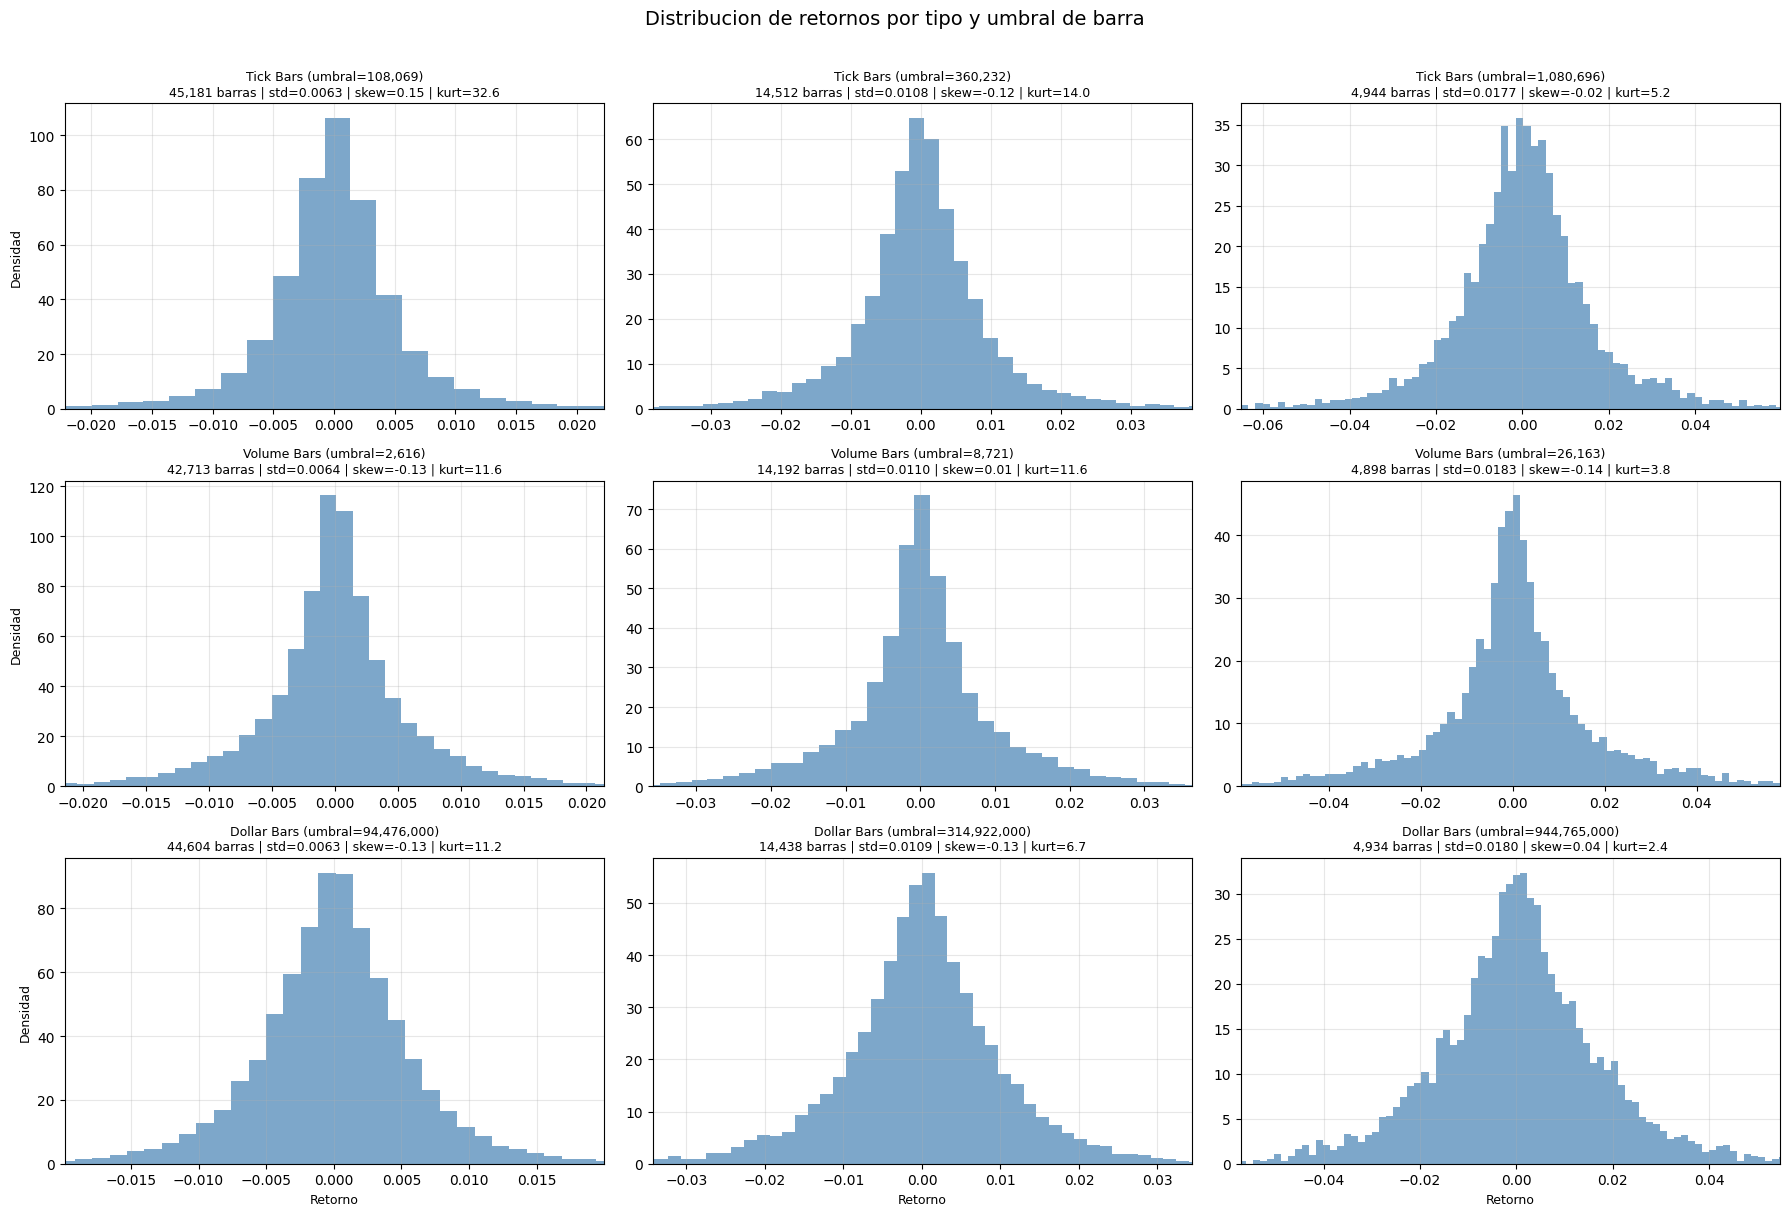

Resumen estadistico de retornos:
Tipo                     Umbral   N barras        Std     Skew     Kurt    AC(1)
---------------------------------------------------------------------------
Tick Bars               108,069     45,181     0.0063    0.146     32.6  -0.0395
Tick Bars               360,232     14,512     0.0108   -0.116     14.0  -0.0228
Tick Bars             1,080,696      4,944     0.0177   -0.019      5.2   0.0063
Volume Bars               2,616     42,713     0.0064   -0.126     11.6  -0.0298
Volume Bars               8,721     14,192     0.0110    0.014     11.6  -0.0188
Volume Bars              26,163      4,898     0.0183   -0.138      3.8   0.0056
Dollar Bars          94,476,000     44,604     0.0063   -0.129     11.2  -0.0316
Dollar Bars         314,922,000     14,438     0.0109   -0.133      6.7  -0.0191
Dollar Bars         944,765,000      4,934     0.0180    0.036      2.4  -0.0085


In [78]:
# --- Grafica comparativa: retornos y autocorrelacion para cada tipo de barra ---
fig, axes = plt.subplots(3, 3, figsize=(18, 12))

for row_idx, (bar_type, thresholds_dict) in enumerate(bar_results.items()):
    for col_idx, (th, bars_df) in enumerate(thresholds_dict.items()):
        ax = axes[row_idx, col_idx]
        returns = bars_df["close"].pct_change().dropna()
        ax.hist(returns, bins=150, alpha=0.7, density=True, color="steelblue", edgecolor="none")

        # Estadisticas en el titulo
        ax.set_title(
            f"{bar_type} (umbral={th:,.0f})\n"
            f"{len(bars_df):,} barras | "
            f"std={returns.std():.4f} | skew={returns.skew():.2f} | kurt={returns.kurtosis():.1f}",
            fontsize=9,
        )
        ax.set_xlim(returns.quantile(0.005), returns.quantile(0.995))
        ax.grid(True, alpha=0.3)
        if col_idx == 0:
            ax.set_ylabel("Densidad", fontsize=9)
        if row_idx == 2:
            ax.set_xlabel("Retorno", fontsize=9)

fig.suptitle("Distribucion de retornos por tipo y umbral de barra", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# Tabla resumen
print("Resumen estadistico de retornos:")
print(f"{'Tipo':<15} {'Umbral':>15} {'N barras':>10} {'Std':>10} {'Skew':>8} {'Kurt':>8} {'AC(1)':>8}")
print("-" * 75)
for bar_type, thresholds_dict in bar_results.items():
    for th, bars_df in thresholds_dict.items():
        r = bars_df["close"].pct_change().dropna()
        ac1 = r.autocorr(lag=1)
        print(f"{bar_type:<15} {th:>15,.0f} {len(bars_df):>10,} {r.std():>10.4f} {r.skew():>8.3f} {r.kurtosis():>8.1f} {ac1:>8.4f}")

La tabla y los histogramas permiten comparar cómo se comportan los retornos según el tipo de barra y el umbral elegido:

- **Curtosis (kurt):** Mide el peso de las colas. Una distribución normal tiene $\kappa = 3$ (aquí se muestra el exceso, por lo que el objetivo es $\approx 0$). Valores altos indican colas pesadas (eventos extremos más frecuentes de lo esperado). Al aumentar el umbral $\theta$, cada barra agrega más información y la curtosis tiende a reducirse, acercándose a la normalidad.
- **Asimetría (skew):** Valores cercanos a 0 indican simetría. En general se mantiene baja para todos los umbrales, lo que indica que las subidas y bajadas son aproximadamente simétricas.
- **Autocorrelación AC(1):** Mide la dependencia entre retornos consecutivos. Para un proceso IID debería ser $\approx 0$. Umbrales más altos tienden a reducir AC(1) porque cada barra es más independiente de la anterior al contener más actividad agregada.

En los tres tipos de barra, el umbral alto produce retornos más cercanos a IID Normal (menor curtosis, menor autocorrelación), pero a costa de tener menos barras para entrenar. El umbral medio suele ofrecer el mejor compromiso.

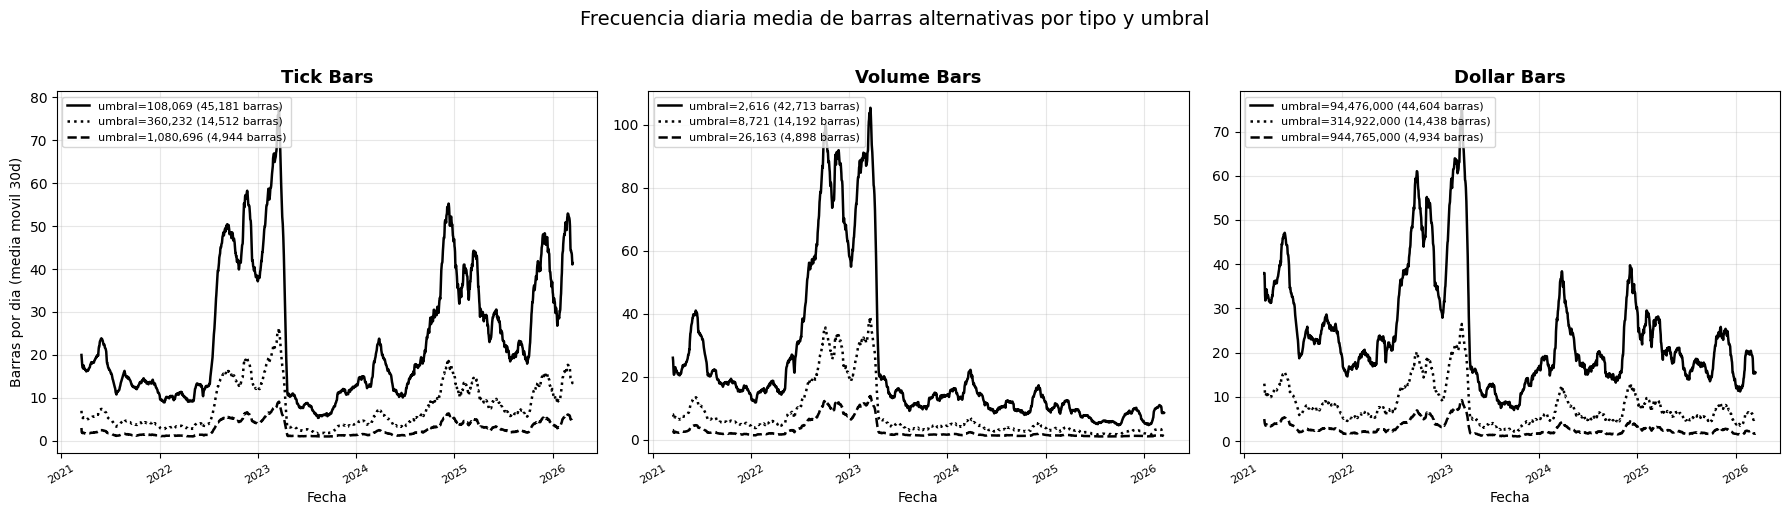

In [79]:
# --- Frecuencia diaria media de cada tipo de barra (estilo MLdP Fig. 2.4) ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)

line_styles = ["-", ":", "--"]
colors_th = ["#1f77b4", "#ff7f0e", "#2ca02c"]

for col_idx, (bar_type, thresholds_dict) in enumerate(bar_results.items()):
    ax = axes[col_idx]
    for i, (th, bars_df) in enumerate(thresholds_dict.items()):
        bars_tmp = bars_df.copy()
        bars_tmp["date"] = pd.to_datetime(bars_tmp["open_time"]).dt.date
        daily_counts = bars_tmp.groupby("date").size()
        daily_counts.index = pd.to_datetime(daily_counts.index)
        rolling_freq = daily_counts.rolling(window=30, min_periods=1).mean()

        ax.plot(rolling_freq.index, rolling_freq.values,
                linestyle=line_styles[i],
                linewidth=1.8,
                color="black",
                label=f"umbral={th:,.0f} ({len(bars_df):,} barras)")

    ax.set_title(bar_type, fontsize=13, fontweight="bold")
    ax.set_xlabel("Fecha", fontsize=10)
    if col_idx == 0:
        ax.set_ylabel("Barras por dia (media movil 30d)", fontsize=10)
    ax.legend(fontsize=8, loc="upper left")
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis="x", rotation=30, labelsize=8)

fig.suptitle("Frecuencia diaria media de barras alternativas por tipo y umbral", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

Con time bars de 5 min siempre hay 288 barras/día, sin importar si el mercado estuvo activo o no. Las barras alternativas generan más barras los días de alta actividad y menos los días tranquilos. Esta variabilidad es deseable: muestreamos más cuando hay más información y menos cuando no pasa nada relevante.

En el gráfico se observa cómo el umbral controla la frecuencia diaria de barras:
- **Umbral bajo:** la curva oscila con valores altos (muchas barras/día), reflejando fielmente los picos de actividad del mercado, pero con mucho ruido día a día.
- **Umbral medio:** suaviza las oscilaciones manteniendo los picos en periodos de alta volatilidad. Es el compromiso más equilibrado.
- **Umbral alto:** la curva es mucho más plana y estable, con pocas barras/día. Los picos de actividad quedan atenuados, perdiendo resolución temporal.

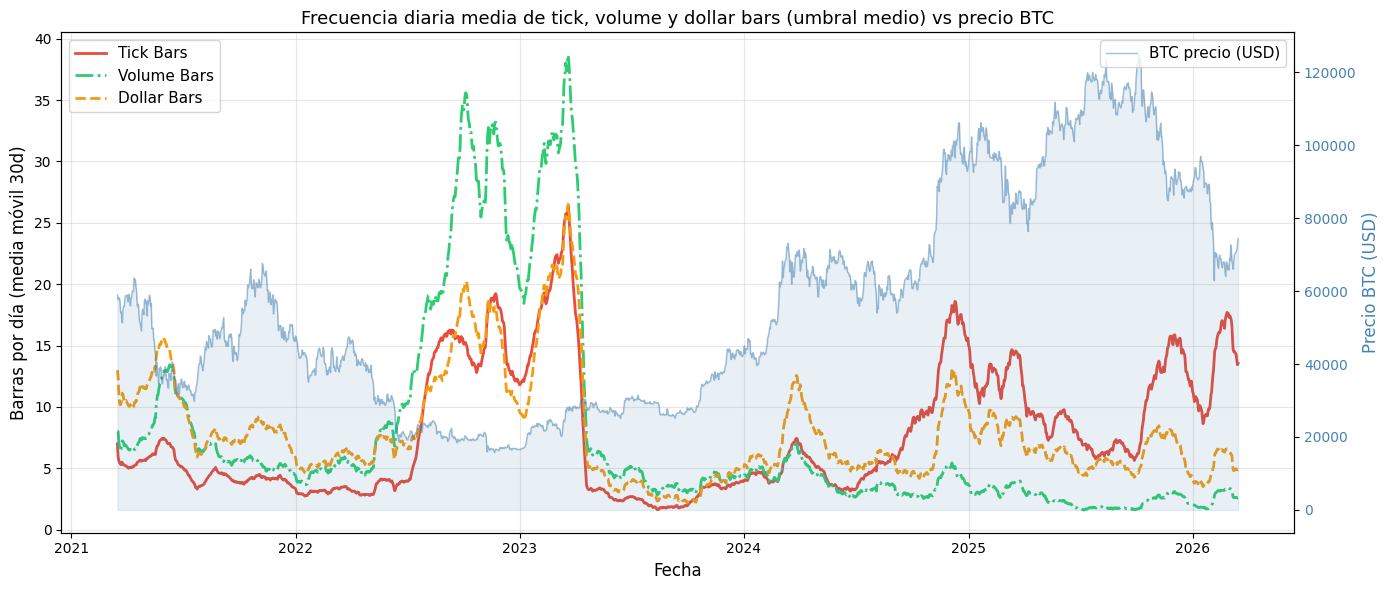

In [80]:
# --- Frecuencia diaria media comparando los 3 tipos de barra + precio BTC ---
fig, ax = plt.subplots(figsize=(14, 6))

bar_colors = {"Tick Bars": "#e74c3c", "Volume Bars": "#2ecc71", "Dollar Bars": "#f39c12"}
line_styles = {"Tick Bars": "-", "Volume Bars": "-.", "Dollar Bars": "--"}

for bar_type, thresholds_dict in bar_results.items():
    th_mid, bars_mid = list(thresholds_dict.items())[1]
    bars_mid = bars_mid.copy()
    bars_mid["date"] = pd.to_datetime(bars_mid["open_time"]).dt.date
    daily_counts = bars_mid.groupby("date").size()
    daily_counts.index = pd.to_datetime(daily_counts.index)
    rolling_freq = daily_counts.rolling(window=30, min_periods=1).mean()

    ax.plot(rolling_freq.index, rolling_freq.values,
            linestyle=line_styles[bar_type],
            linewidth=2,
            color=bar_colors[bar_type],
            label=bar_type)

ax.set_xlabel("Fecha", fontsize=12)
ax.set_ylabel("Barras por día (media móvil 30d)", fontsize=12)
ax.set_title("Frecuencia diaria media de tick, volume y dollar bars (umbral medio) vs precio BTC", fontsize=13)
ax.legend(loc="upper left", fontsize=11)
ax.grid(True, alpha=0.3)

# Eje secundario: precio de cierre diario de BTC
ax2 = ax.twinx()
btc_daily = df.copy()
btc_daily["date"] = pd.to_datetime(btc_daily["open_time"]).dt.date
btc_close = btc_daily.groupby("date")["close"].last()
btc_close.index = pd.to_datetime(btc_close.index)
ax2.fill_between(btc_close.index, btc_close.values, alpha=0.12, color="steelblue")
ax2.plot(btc_close.index, btc_close.values, color="steelblue", alpha=0.5, linewidth=1, label="BTC precio (USD)")
ax2.set_ylabel("Precio BTC (USD)", fontsize=12, color="steelblue")
ax2.tick_params(axis="y", labelcolor="steelblue")
ax2.legend(loc="upper right", fontsize=11)

fig.tight_layout()
plt.show()

Este gráfico compara la media móvil (30 días) de barras diarias para los tres tipos, usando el umbral medio de cada uno. Se pueden extraer varias conclusiones:

- **Tick Bars y Volume Bars co-varían con el precio de BTC:** cuando Bitcoin sube, el volumen nominal (en BTC) necesario para cerrar una barra se alcanza con menos unidades (porque cada unidad vale más), disparando el número de barras/día. La curva de Dollar Bars es mucho más plana porque el umbral ya está en USD ($\theta = P \times V$), absorbiendo ese efecto.
- **Los picos coinciden con eventos de mercado:** los máximos de frecuencia diaria en las tres curvas se alinean con periodos de alta volatilidad (crashes, rallies). Pero en Tick y Volume Bars estos picos son más pronunciados y asimétricos, mientras que en Dollar Bars se amortiguan.
- **Implicación para ML:** una frecuencia diaria muy variable significa que el modelo recibe cantidades de datos muy distintas según el periodo. Esto puede sesgar el entrenamiento hacia periodos de alta actividad. Las Dollar Bars minimizan este problema al mantener una tasa de muestreo más homogénea en el tiempo.

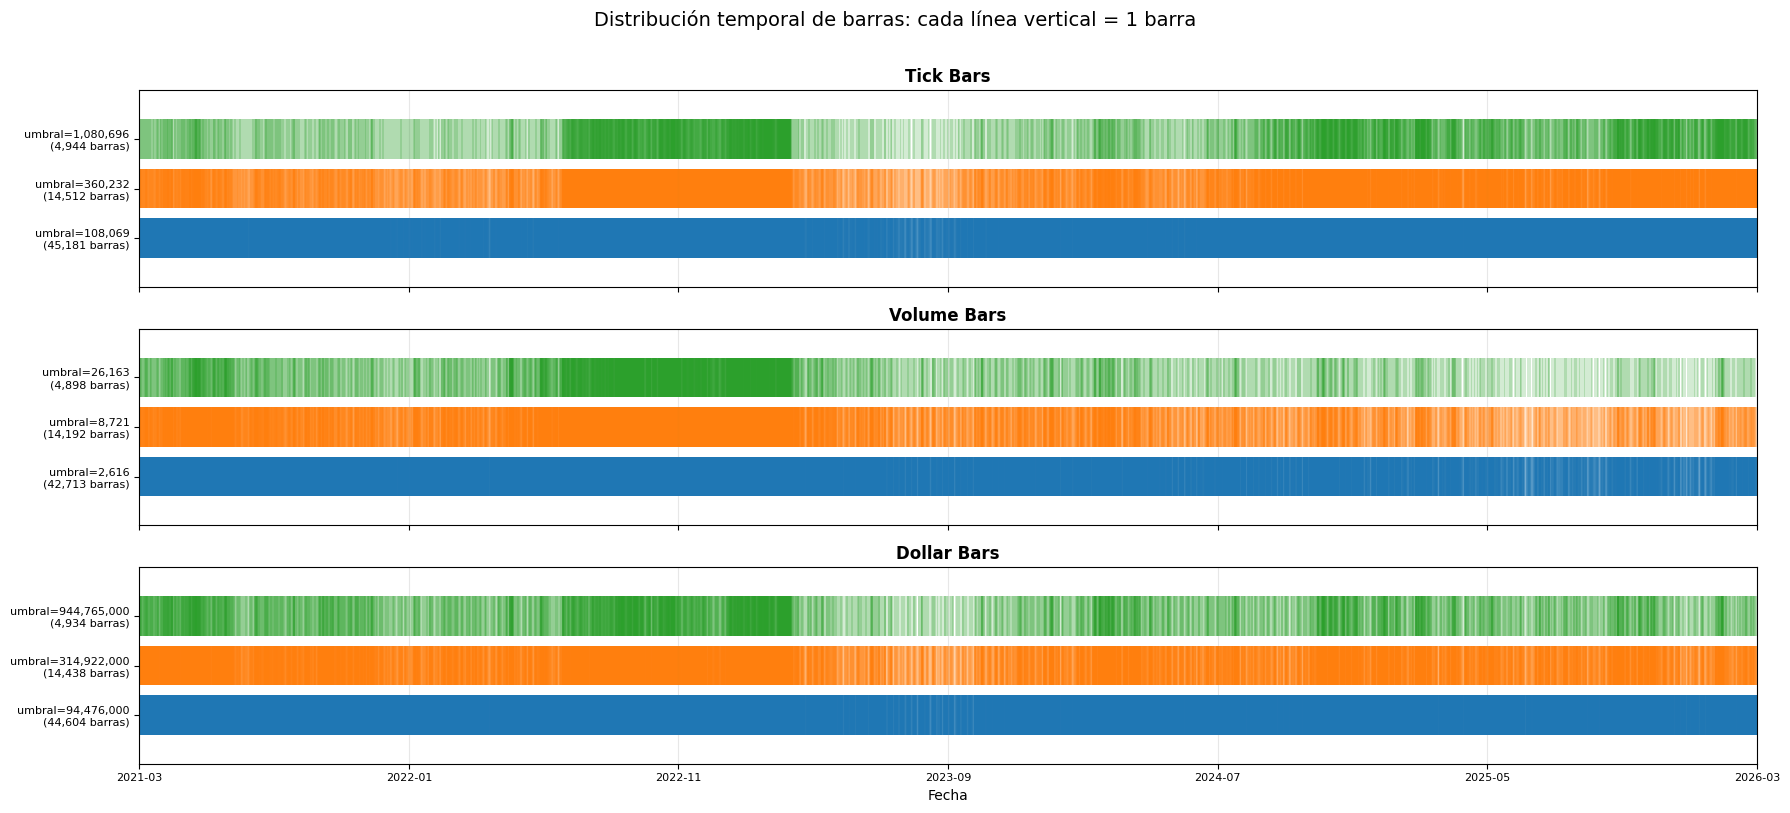

In [81]:
# --- Event plot: marcas verticales en la línea temporal para cada barra ---
fig, axes = plt.subplots(3, 1, figsize=(18, 8), sharex=True)

colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]

for row_idx, (bar_type, thresholds_dict) in enumerate(bar_results.items()):
    ax = axes[row_idx]
    th_list = list(thresholds_dict.items())
    for i, (th, bars_df) in enumerate(th_list):
        # Convertir timestamps a matplotlib dates
        times = bars_df["open_time"].values
        # eventplot espera valores numéricos
        times_num = pd.to_datetime(times).map(lambda x: x.timestamp())
        ax.eventplot(
            [times_num],
            lineoffsets=i,
            linelengths=0.8,
            linewidths=0.3,
            colors=[colors[i]],
        )
    ax.set_yticks(range(len(th_list)))
    ax.set_yticklabels([f"umbral={th:,.0f}\n({len(b):,} barras)" for th, b in th_list], fontsize=8)
    ax.set_title(bar_type, fontsize=12, fontweight="bold")
    ax.grid(True, axis="x", alpha=0.3)

# Convertir eje x a fechas legibles
import matplotlib.dates as mdates
for ax in axes:
    # Reescalar eje x con fechas
    ax.set_xlim(
        pd.Timestamp(START_DATE).timestamp(),
        pd.Timestamp(END_DATE).timestamp(),
    )
    # Poner ticks con fechas
    xticks = pd.date_range(START_DATE, END_DATE, periods=7)
    ax.set_xticks([t.timestamp() for t in xticks])
    ax.set_xticklabels([t.strftime("%Y-%m") for t in xticks], fontsize=8)

axes[-1].set_xlabel("Fecha")
fig.suptitle("Distribución temporal de barras: cada línea vertical = 1 barra", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

El *event plot* muestra visualmente cuándo se cierra cada barra. Se ve claramente cómo las marcas se agrupan en periodos volátiles (más actividad → el umbral se alcanza antes → más barras por unidad de tiempo) y se espacian en periodos tranquilos. También se aprecia la diferencia entre umbrales: el bajo genera muchas marcas, el medio una cantidad moderada, y el alto pocas marcas, evidenciando el trade-off entre cantidad de datos y calidad estadística.

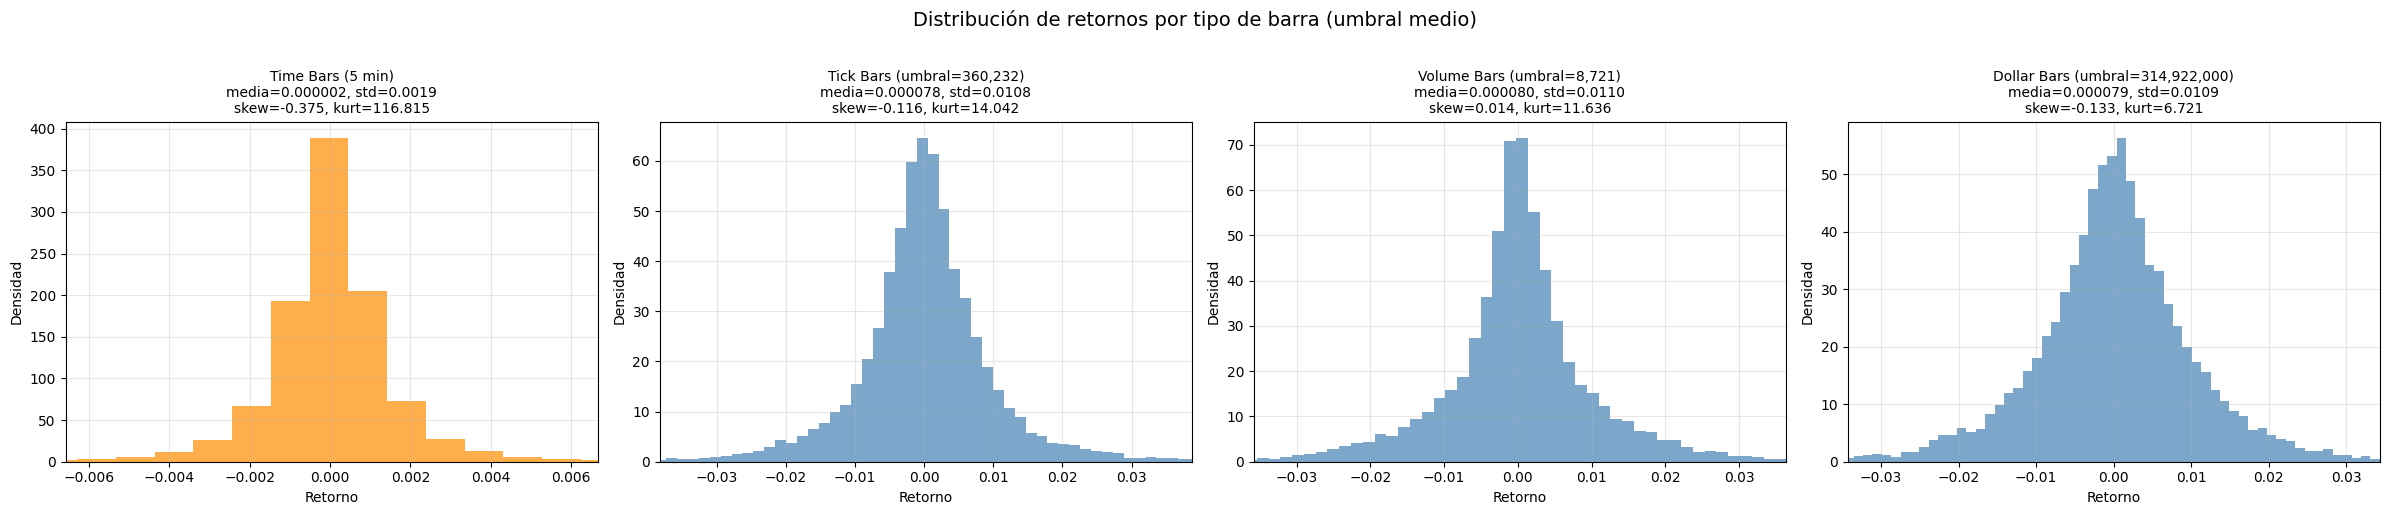


Resumen de retornos (umbral medio de cada tipo):
Tipo              N barras        Media        Std     Skew     Kurt
-----------------------------------------------------------------
Time Bars          525,877     0.000002     0.0019   -0.375  116.815
Tick Bars           14,512     0.000078     0.0108   -0.116   14.042
Volume Bars         14,192     0.000080     0.0110    0.014   11.636
Dollar Bars         14,438     0.000079     0.0109   -0.133    6.721


In [82]:
# --- Comparar propiedades estadísticas: retornos de cada tipo de barra ---
fig, axes = plt.subplots(1, 4, figsize=(24, 5))

# 1) Time Bars (velas de 5 min originales)
ax = axes[0]
returns_time = df["close"].pct_change().dropna()
ax.hist(returns_time, bins=200, alpha=0.7, density=True, color="darkorange")
ax.set_title(f"Time Bars (5 min)\n"
             f"media={returns_time.mean():.6f}, std={returns_time.std():.4f}\n"
             f"skew={returns_time.skew():.3f}, kurt={returns_time.kurtosis():.3f}",
             fontsize=10)
ax.set_xlabel("Retorno")
ax.set_ylabel("Densidad")
ax.set_xlim(returns_time.quantile(0.005), returns_time.quantile(0.995))
ax.grid(True, alpha=0.3)

# 2) Barras alternativas (umbral medio de cada tipo)
for col_idx, (bar_type, thresholds_dict) in enumerate(bar_results.items()):
    ax = axes[col_idx + 1]
    thresholds_list = list(thresholds_dict.items())
    # Umbral medio
    th_mid, bars_mid = thresholds_list[1]
    returns = bars_mid["close"].pct_change().dropna()

    ax.hist(returns, bins=200, alpha=0.7, density=True, color="steelblue")
    ax.set_title(f"{bar_type} (umbral={th_mid:,.0f})\n"
                 f"media={returns.mean():.6f}, std={returns.std():.4f}\n"
                 f"skew={returns.skew():.3f}, kurt={returns.kurtosis():.3f}",
                 fontsize=10)
    ax.set_xlabel("Retorno")
    ax.set_ylabel("Densidad")
    ax.set_xlim(returns.quantile(0.005), returns.quantile(0.995))
    ax.grid(True, alpha=0.3)

fig.suptitle("Distribución de retornos por tipo de barra (umbral medio)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Tabla resumen
print("\nResumen de retornos (umbral medio de cada tipo):")
print(f"{'Tipo':<15} {'N barras':>10} {'Media':>12} {'Std':>10} {'Skew':>8} {'Kurt':>8}")
print("-" * 65)
r_time = df["close"].pct_change().dropna()
print(f"{'Time Bars':<15} {len(df):>10,} {r_time.mean():>12.6f} {r_time.std():>10.4f} {r_time.skew():>8.3f} {r_time.kurtosis():>8.3f}")
for bar_type, thresholds_dict in bar_results.items():
    th_mid, bars_mid = list(thresholds_dict.items())[1]
    r = bars_mid["close"].pct_change().dropna()
    print(f"{bar_type:<15} {len(bars_mid):>10,} {r.mean():>12.6f} {r.std():>10.4f} {r.skew():>8.3f} {r.kurtosis():>8.3f}")

Esta comparación directa entre Time Bars y las tres barras alternativas (todas con umbral medio) permite ver las diferencias clave:

- **Curtosis (kurt):** Las Time Bars presentan la curtosis más alta, lo que indica colas pesadas (eventos extremos más frecuentes de lo esperado bajo normalidad). Las barras alternativas la reducen progresivamente: Tick > Volume > Dollar, acercándose a $\kappa = 0$ (valor de la normal).
- **Asimetría (skew):** Similar en todos los tipos, cercana a 0, lo que indica que no hay un sesgo sistemático alcista o bajista en los retornos.
- **Desviación estándar (std):** Las barras alternativas tienen mayor std que las Time Bars porque cada barra agrega más actividad. Esto no es un problema — simplemente refleja que cada retorno contiene más información.
- **Forma del histograma:** Las Time Bars muestran un pico central muy pronunciado con colas largas (distribución leptocúrtica). Las Dollar Bars producen la forma más suave y simétrica, más cercana a la campana gaussiana que necesitan los modelos de ML.

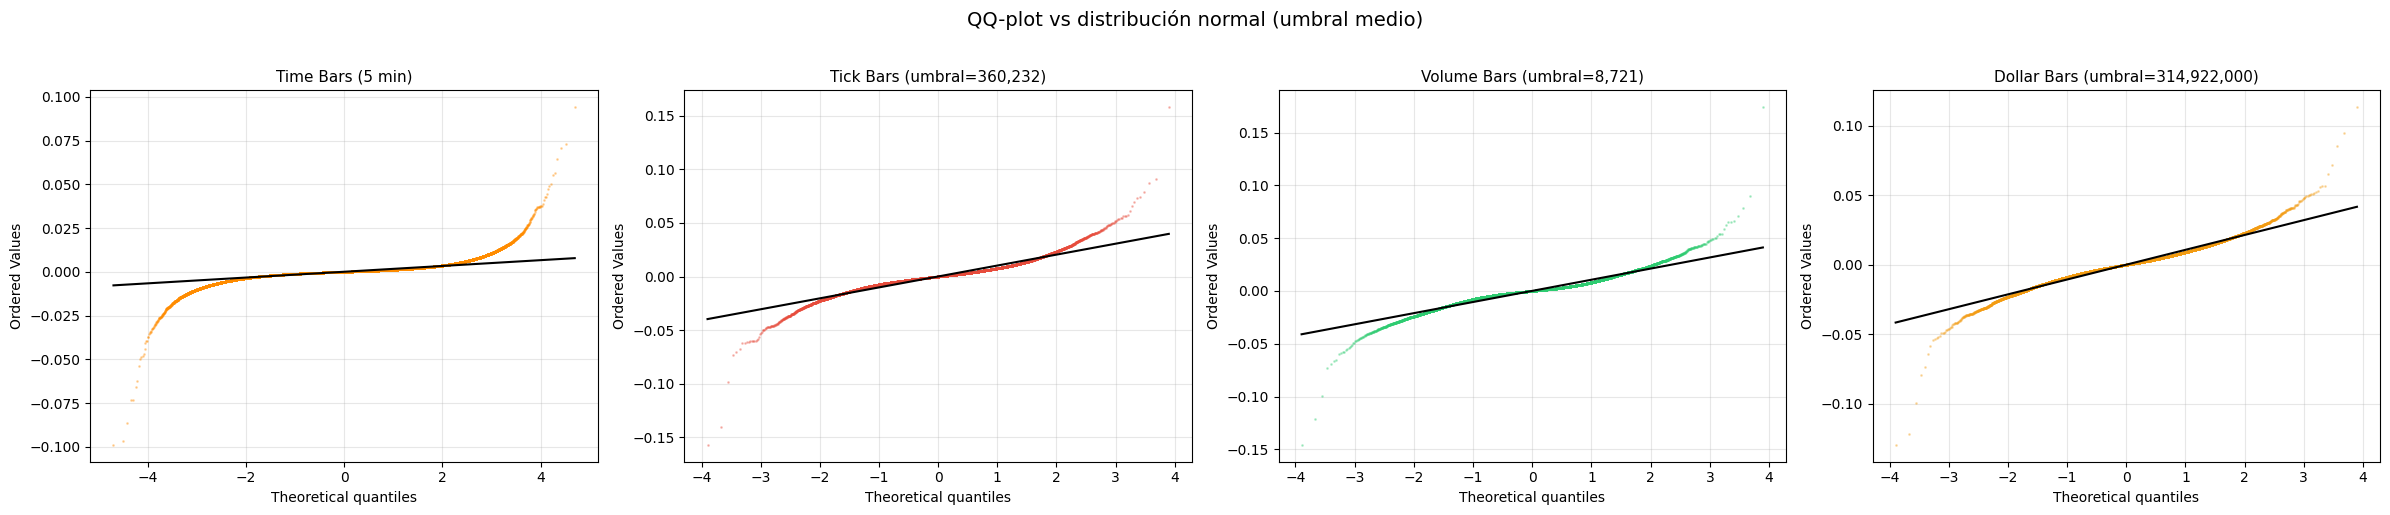

In [83]:
# --- QQ-plot: ajuste a la normal para cada tipo de barra (umbral medio) ---
from scipy import stats

fig, axes = plt.subplots(1, 4, figsize=(24, 5))

# 1) Time Bars
returns_time = df["close"].pct_change().dropna()
stats.probplot(returns_time, dist="norm", plot=axes[0])
axes[0].set_title("Time Bars (5 min)", fontsize=11)
axes[0].get_lines()[0].set(markersize=1, alpha=0.3, color="darkorange")
axes[0].get_lines()[1].set(color="black", linewidth=1.5)
axes[0].grid(True, alpha=0.3)

# 2) Barras alternativas (umbral medio)
bar_colors = {"Tick Bars": "#e74c3c", "Volume Bars": "#2ecc71", "Dollar Bars": "#f39c12"}
for col_idx, (bar_type, thresholds_dict) in enumerate(bar_results.items()):
    ax = axes[col_idx + 1]
    th_mid, bars_mid = list(thresholds_dict.items())[1]
    returns = bars_mid["close"].pct_change().dropna()
    stats.probplot(returns, dist="norm", plot=ax)
    ax.set_title(f"{bar_type} (umbral={th_mid:,.0f})", fontsize=11)
    ax.get_lines()[0].set(markersize=1, alpha=0.3, color=bar_colors[bar_type])
    ax.get_lines()[1].set(color="black", linewidth=1.5)
    ax.grid(True, alpha=0.3)

fig.suptitle("QQ-plot vs distribución normal (umbral medio)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

En un QQ-plot, si los retornos fueran perfectamente normales, todos los puntos caerían sobre la línea diagonal negra. Las desviaciones en las colas revelan el grado de no-normalidad:

- **Time Bars:** las colas se separan notablemente de la diagonal, indicando eventos extremos mucho más frecuentes de lo que predice una normal (colas pesadas). Es el peor ajuste de los cuatro.
- **Tick y Volume Bars:** mejoran respecto a Time Bars — los puntos siguen la diagonal en la zona central, pero las colas aún se desvían, especialmente la cola izquierda (caídas bruscas).
- **Dollar Bars:** presentan el ajuste lijeramente más cercano a la diagonal en todo el rango, incluidas las colas que las barras alternativas analizadas. Aunque tienen aún descviaciones en las colas. Esto confirma cuantitativamente lo que ya sugerían los histogramas y la curtosis: las Dollar Bars producen los retornos más compatibles con la hipótesis gaussiana.

### Resumen sobre las barras alternativas

**Umbral y número de barras:** A mayor umbral $\theta$, menos barras. La relación es directa: $N \approx \sum x_t / \theta$. Hay un trade-off entre tener muchas barras (más datos para entrenar) y barras con suficiente información cada una.

**¿Por qué no usar time bars según Lopez del Prado?** Las time bars generan siempre el mismo número de barras por hora, sin importar si el mercado está activo o dormido. Esto produce retornos con autocorrelación ($\rho_1 \neq 0$) y heterocedasticidad (varianza que cambia con el tiempo), dos propiedades indeseables para ML.

**Comparación de los tres tipos:**
- **Tick Bars** ($x_t = 1$ por trade): las más simples. Mejoran sobre time bars, pero son sensibles a fragmentación de órdenes (una operación grande puede aparecer como muchos ticks).
- **Volume Bars** ($x_t = V_t$): mejoran sobre tick bars al ser inmunes a fragmentación. Pero si el precio sube mucho, se necesitan menos unidades para alcanzar $\theta$, generando más barras sin que haya más actividad real.
- **Dollar Bars** ($x_t = P_t \cdot V_t$): las más robustas. Al medir en USD, neutralizan el efecto de cambios de precio. Producen retornos con menor curtosis y autocorrelación. 

**Conclusión:** Seleccionamos Dollar Bars con umbral medio para el resto del análisis.

In [84]:
# --- Seleccionar Dollar Bars (umbral medio) para las siguientes secciones ---
dollar_mid_th = list(bar_results["Dollar Bars"].keys())[1]
df_bars = bar_results["Dollar Bars"][dollar_mid_th].copy()
df_bars.reset_index(drop=True, inplace=True)

print(f"Seleccionadas Dollar Bars con umbral = {dollar_mid_th:,.0f} USDT")
print(f"Total barras: {len(df_bars):,}")
display(df_bars.head())

Seleccionadas Dollar Bars con umbral = 314,922,000 USDT
Total barras: 14,438


,open_time,close_time,open,high,low,close,volume,quote_volume,num_trades
0,2021-03-17 00:00:00.000,2021-03-17 02:29:59.999,56900.74,57189.43,55756.59,55962.88,5718.041383,3.228319e+08,215565
1,2021-03-17 02:29:59.999,2021-03-17 05:44:59.999,55962.88,56152.41,55185.42,55711.29,5725.287952,3.187948e+08,223333
2,2021-03-17 05:44:59.999,2021-03-17 08:29:59.999,55711.29,56326.53,55622.94,55926.96,5727.965137,3.206372e+08,192087
3,2021-03-17 08:29:59.999,2021-03-17 09:59:59.999,55926.96,55991.76,54326.27,54762.77,5865.818082,3.236095e+08,156549
4,2021-03-17 09:59:59.999,2021-03-17 12:14:59.999,54762.77,55234.88,54260.00,54260.00,6049.944672,3.319256e+08,213904


## 3. Diferenciación fraccional

En esta sección trabajamos sobre la serie de precios *close* de las **Dollar Bars** (umbral medio) construidas en el Apartado 1.

En series financieras existe un trade-off entre **estacionariedad** y **memoria**:

- Diferenciar con *d=1* (retornos) hace la serie estacionaria, pero destruye toda la memoria (relación con niveles pasados de precio).
- No diferenciar (*d=0*, precio en niveles) conserva la memoria, pero la serie es no estacionaria y viola supuestos de muchos modelos ML.

Lopez de Prado (2018, Cap. 5) propone la **diferenciación fraccional** con *0 < d < 1*, que permite encontrar el mínimo *d* que hace la serie estacionaria conservando la mayor cantidad de memoria posible.

La serie diferenciada fraccionalmente se obtiene aplicando el operador:

$$\tilde{X}_t = \sum_{k=0}^{\infty} w_k \, X_{t-k}, \quad w_k = -w_{k-1} \frac{d - k + 1}{k}$$

donde los pesos $w_k$ decaen lentamente (se truncan cuando $|w_k| < \tau$, con $\tau = 10^{-5}$ por defecto).

Compararemos valores de *d* ∈ {0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0} (incrementos de 0.1) y evaluaremos la estacionariedad con el test ADF.

In [85]:
%pip install statsmodels --quiet

Note: you may need to restart the kernel to use updated packages.


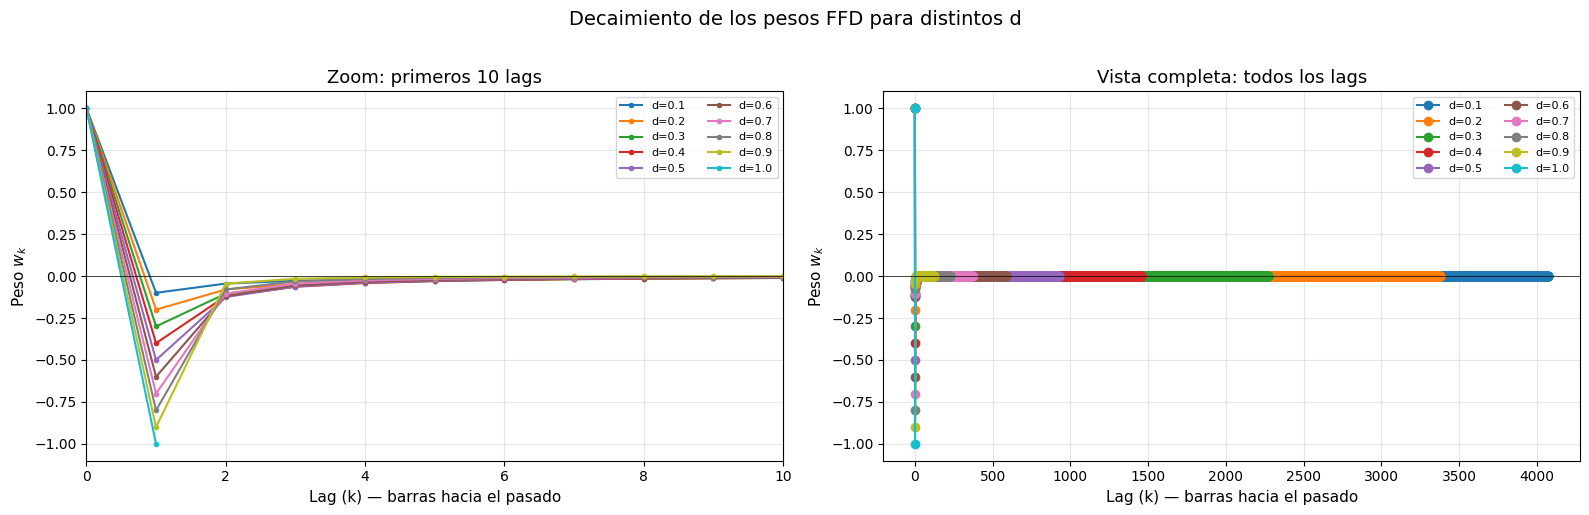

In [86]:
from statsmodels.tsa.stattools import adfuller


def get_weights_ffd(d, threshold=1e-5):
    """
    Calcula los pesos para la diferenciación fraccional (Fixed-Width Window).
    Los pesos se truncan cuando |w_k| < threshold.
    (Lopez de Prado, 2018, Snippet 5.3)
    """
    w = [1.0]
    k = 1
    while True:
        w_k = -w[-1] * (d - k + 1) / k
        if abs(w_k) < threshold:
            break
        w.append(w_k)
        k += 1
    return np.array(w[::-1])


def frac_diff_ffd(series, d, threshold=1e-5):
    """
    Aplica diferenciación fraccional FFD a una serie.
    (Lopez de Prado, 2018, Snippet 5.4)
    
    Parámetros:
        series: pd.Series con los precios.
        d: orden de diferenciación fraccional.
        threshold: umbral para truncar pesos.
    
    Retorna:
        pd.Series con la serie diferenciada fraccionalmente.
    """
    weights = get_weights_ffd(d, threshold)
    width = len(weights)
    result = {}
    series_values = series.values

    for i in range(width - 1, len(series_values)):
        window = series_values[i - width + 1: i + 1]
        result[series.index[i]] = np.dot(weights, window)

    return pd.Series(result, dtype=float)


# --- Gráfica: decaimiento de los pesos FFD para distintos d ---
# Precalcular pesos por lag para cada d
d_plot_values = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
weights_by_d = {}
for d in d_plot_values:
    w = get_weights_ffd(d, threshold=1e-5)
    weights_by_d[d] = w[::-1]  # invertir: lag 0 = dato actual (w=1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# --- Panel izquierdo: zoom a los primeros 10 lags ---
for d in d_plot_values:
    w_by_lag = weights_by_d[d]
    lags = np.arange(len(w_by_lag))
    ax1.plot(lags, w_by_lag, linewidth=1.5, marker="o", markersize=3, label=f"d={d:.1f}")

ax1.set_xlim(0, 10)
ax1.set_xlabel("Lag (k) — barras hacia el pasado", fontsize=11)
ax1.set_ylabel("Peso $w_k$", fontsize=11)
ax1.set_title("Zoom: primeros 10 lags", fontsize=13)
ax1.axhline(0, color="black", linewidth=0.5)
ax1.legend(fontsize=8, ncol=2)
ax1.grid(True, alpha=0.3)

# --- Panel derecho: vista completa ---
for d in d_plot_values:
    w_by_lag = weights_by_d[d]
    lags = np.arange(len(w_by_lag))
    ax2.plot(lags, w_by_lag, linewidth=1.5, marker="o", label=f"d={d:.1f}")

ax2.set_xlabel("Lag (k) — barras hacia el pasado", fontsize=11)
ax2.set_ylabel("Peso $w_k$", fontsize=11)
ax2.set_title("Vista completa: todos los lags", fontsize=13)
ax2.axhline(0, color="black", linewidth=0.5)
ax2.legend(fontsize=8, ncol=2)
ax2.grid(True, alpha=0.3)

fig.suptitle("Decaimiento de los pesos FFD para distintos d", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

**Interpretación del gráfico de decaimiento de pesos FFD:**

Para calcular cada valor diferenciado $\tilde{X}_t$, se hace una suma ponderada del precio actual y de los precios pasados: $\tilde{X}_t = w_0 \cdot X_t + w_1 \cdot X_{t-1} + w_2 \cdot X_{t-2} + \ldots$ Este gráfico muestra esos pesos $w_k$ para cada valor de $d$.

- **Eje X — Lag ($k$):** Cuántas barras hacia atrás miramos. Lag 0 = precio actual, lag 1 = precio de la barra anterior, lag 2 = dos barras atrás, etc.
- **Eje Y — Peso ($w_k$):** Cuánto "pesa" cada precio pasado en el cálculo. El precio actual siempre tiene peso 1. Los precios más antiguos tienen pesos cada vez más pequeños (y negativos), es decir, influyen menos.

**Qué se observa:**
- **$d$ bajo (ej. 0.1, 0.2):** Los pesos decaen muy lentamente y la curva se extiende miles de lags. Esto significa que el precio de hace muchas barras todavía influye en $\tilde{X}_t$ → se conserva mucha **memoria** de la serie original.
- **$d$ alto (ej. 0.8, 0.9):** Los pesos caen rápidamente a cero en pocos lags → solo importan las barras más recientes y se pierde la memoria del pasado lejano.
- **$d = 1$:** Solo existen dos pesos ($+1$ para $X_t$ y $-1$ para $X_{t-1}$), que es exactamente el retorno simple $X_t - X_{t-1}$. Toda la memoria se destruye.

**¿Por qué los pesos bajan (se hacen negativos) y luego vuelven a subir hacia cero?** La fórmula recursiva de los pesos es $w_k = -w_{k-1} \cdot \frac{d - k + 1}{k}$. En los primeros lags el factor $\frac{d-k+1}{k}$ es grande y negativo, lo que hace que los pesos caigan rápidamente por debajo de cero: la diferenciación *resta* la influencia de las barras recientes para eliminar la tendencia. A medida que $k$ crece, el factor $\frac{d-k+1}{k}$ se va haciendo cada vez más pequeño en valor absoluto (el numerador decrece y el denominador crece), por lo que cada peso sucesivo cambia muy poco respecto al anterior y la curva se aplana, convergiendo lentamente hacia cero. Este comportamiento es el que permite conservar memoria: los precios lejanos siguen teniendo un peso pequeño pero no nulo.

En resumen: cuanto más plana y larga es la curva, más memoria conserva esa diferenciación.

In [87]:
# --- Aplicar diferenciación fraccional con varios d ---
d_values = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
close_series = df_bars["close"].reset_index(drop=True)

frac_diff_results = {}
for d in d_values:
    if d == 0.0:
        frac_diff_results[d] = close_series.copy()
    elif d == 1.0:
        frac_diff_results[d] = close_series.diff().dropna()
    else:
        frac_diff_results[d] = frac_diff_ffd(close_series, d)
    print(f"d={d:.1f}: {len(frac_diff_results[d]):,} valores")

d=0.0: 14,438 valores
d=0.1: 10,363 valores
d=0.2: 11,057 valores
d=0.3: 12,164 valores
d=0.4: 12,981 valores
d=0.5: 13,512 valores
d=0.6: 13,849 valores
d=0.7: 14,067 valores
d=0.8: 14,211 valores
d=0.9: 14,314 valores
d=1.0: 14,437 valores


Hay un "valle" en el número de valores para $d$ intermedios porque es precisamente ahí donde la memoria es más larga (más lags con pesos significativos) y, por tanto, la ventana FFD consume más observaciones al inicio de la serie.

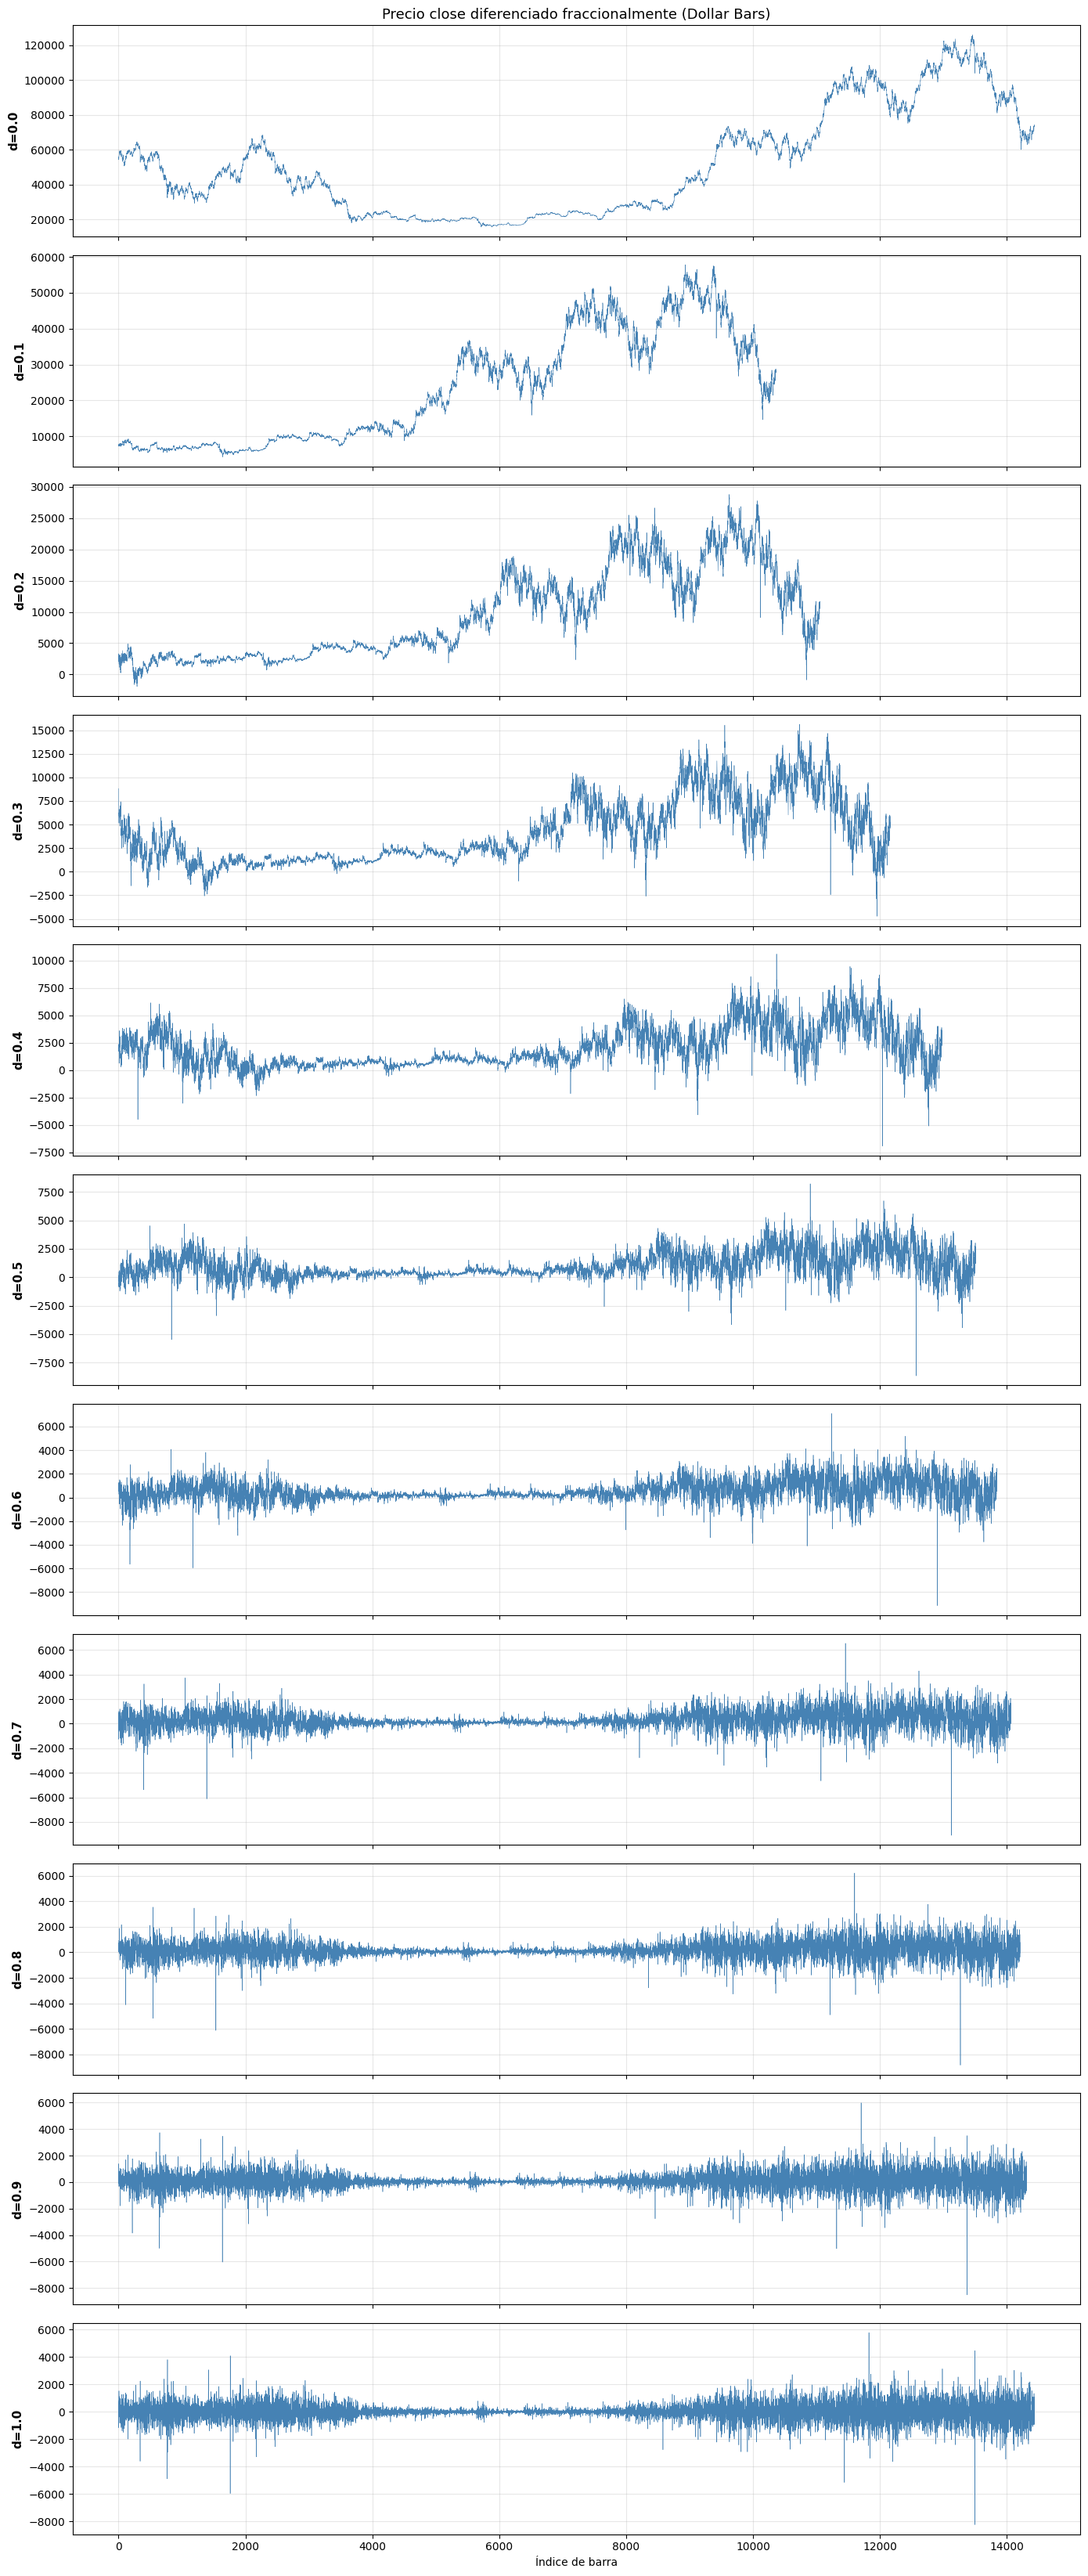

In [88]:
# --- Gráfica: series diferenciadas fraccionalmente ---
fig, axes = plt.subplots(len(d_values), 1, figsize=(14, 3 * len(d_values)), sharex=True)

for i, d in enumerate(d_values):
    s = frac_diff_results[d]
    axes[i].plot(s.values, linewidth=0.4, color="steelblue")
    axes[i].set_ylabel(f"d={d:.1f}", fontsize=11, fontweight="bold")
    axes[i].grid(True, alpha=0.3)

axes[0].set_title("Precio close diferenciado fraccionalmente (Dollar Bars)", fontsize=13)
axes[-1].set_xlabel("Índice de barra")
plt.tight_layout()
plt.show()

Cada panel muestra la serie de precios *close* de las Dollar Bars tras aplicar el operador $(1-B)^d$ con un $d$ distinto. De arriba a abajo se observa una transición gradual:

- **$d=0$ (panel superior):** Es el precio original. Se ve una clara tendencia y estructura de largo plazo — la serie no es estacionaria.
- **$d$ bajo (0.1–0.3):** La tendencia se va atenuando pero la serie conserva "forma" y oscilaciones amplias. Aún se reconoce la dinámica del precio original — se mantiene memoria.
- **$d$ intermedio (0.4–0.6):** La tendencia prácticamente desaparece y la serie empieza a oscilar alrededor de cero. Es la zona donde se logra estacionariedad sin perder toda la memoria.
- **$d$ alto (0.7–0.9):** La serie parece ruido centrado en cero, muy similar a retornos. Queda poca memoria del nivel de precios.
- **$d=1$ (panel inferior):** Son los retornos simples $X_t - X_{t-1}$. Serie estacionaria pero sin ninguna relación visible con el nivel de precios original.

La clave es encontrar el $d$ más bajo donde la serie ya "parece" estacionaria (se confirma con el test ADF a continuación) — ese es el que mejor equilibra memoria y estacionariedad.

In [89]:
# --- Test ADF para cada d: evaluar estacionariedad ---
adf_results = []
for d in d_values:
    s = frac_diff_results[d].dropna()
    adf_stat, p_value, _, _, critical_values, _ = adfuller(s, maxlag=1)
    adf_results.append({
        "d": d,
        "ADF Statistic": adf_stat,
        "p-value": p_value,
        "Estacionaria (p<0.05)": "Sí" if p_value < 0.05 else "No",
        "1% CV": critical_values["1%"],
        "5% CV": critical_values["5%"],
    })

df_adf = pd.DataFrame(adf_results)
display(df_adf)

,d,ADF Statistic,p-value,Estacionaria (p<0.05),1% CV,5% CV
0,0.0,-1.086902,7.202667e-01,No,-3.430803,-2.861740
1,0.1,-1.982779,2.941746e-01,No,-3.430981,-2.861819
2,0.2,-3.901175,2.026218e-03,Sí,-3.430942,-2.861801
3,0.3,-8.331325,3.362400e-13,Sí,-3.430888,-2.861778
4,0.4,-15.989502,6.695751e-29,Sí,-3.430854,-2.861763
5,0.5,-27.019533,0.000000e+00,Sí,-3.430834,-2.861754
6,0.6,-40.746132,0.000000e+00,Sí,-3.430822,-2.861749
7,0.7,-54.623603,0.000000e+00,Sí,-3.430815,-2.861746
8,0.8,-67.093198,0.000000e+00,Sí,-3.430810,-2.861743
9,0.9,-77.895345,0.000000e+00,Sí,-3.430807,-2.861742


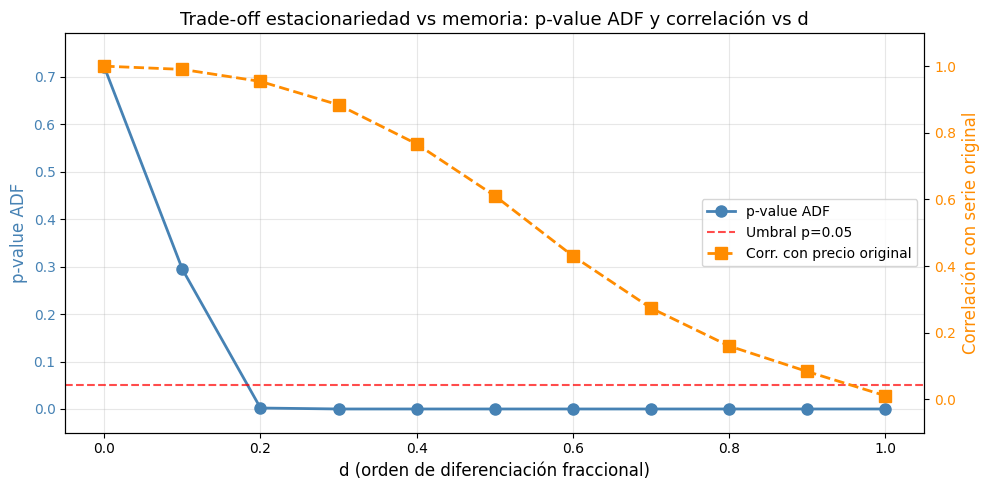


Mínimo d para estacionariedad (p < 0.05): d = 0.2
Correlación con precio original en d=0.2: 0.9542


In [90]:
# --- Gráfica: p-value ADF vs d + correlación con serie original ---
fig, ax1 = plt.subplots(figsize=(10, 5))

# p-value ADF
color_adf = "steelblue"
ax1.plot(df_adf["d"], df_adf["p-value"], "o-", color=color_adf, linewidth=2, markersize=8, label="p-value ADF")
ax1.axhline(0.05, color="red", linestyle="--", alpha=0.7, label="Umbral p=0.05")
ax1.set_xlabel("d (orden de diferenciación fraccional)", fontsize=12)
ax1.set_ylabel("p-value ADF", color=color_adf, fontsize=12)
ax1.tick_params(axis="y", labelcolor=color_adf)
ax1.set_ylim(-0.05, max(df_adf["p-value"].max() * 1.1, 0.1))

# Correlación con serie original (eje derecho)
ax2 = ax1.twinx()
color_corr = "darkorange"
correlations = []
for d in d_values:
    s = frac_diff_results[d].dropna()
    common_idx = close_series.index.intersection(s.index)
    corr = close_series.loc[common_idx].corr(s.loc[common_idx])
    correlations.append(corr)

ax2.plot(d_values, correlations, "s--", color=color_corr, linewidth=2, markersize=8, label="Corr. con precio original")
ax2.set_ylabel("Correlación con serie original", color=color_corr, fontsize=12)
ax2.tick_params(axis="y", labelcolor=color_corr)
ax2.set_ylim(-0.1, 1.1)

# Leyenda combinada
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="center right", fontsize=10)

ax1.set_title("Trade-off estacionariedad vs memoria: p-value ADF y correlación vs d", fontsize=13)
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Identificar d mínimo estacionario
d_min_stationary = df_adf.loc[df_adf["p-value"] < 0.05, "d"].min()
print(f"\nMínimo d para estacionariedad (p < 0.05): d = {d_min_stationary:.1f}")
print(f"Correlación con precio original en d={d_min_stationary:.1f}: {correlations[d_values.index(d_min_stationary)]:.4f}")

Este gráfico resume el trade-off central de la diferenciación fraccional en un solo panel con dos ejes:

- **Eje Y izquierdo (azul) — p-value del test ADF:** Mide si la serie es estacionaria. Cuando el p-value cae por debajo de la línea roja ($p = 0.05$), podemos rechazar la hipótesis de raíz unitaria y considerar la serie estacionaria. A mayor $d$, menor p-value (más estacionaria).
- **Eje Y derecho (naranja) — Correlación con el precio original:** Mide cuánta memoria conserva la serie diferenciada. Un valor cercano a 1 indica que la serie transformada aún "se parece" al precio original (conserva información de nivel). A mayor $d$, menor correlación (se pierde memoria).
- **Eje X — $d$:** Orden de diferenciación fraccional, de 0 (sin diferenciar) a 1 (retornos).

Que se observa:
 - $d=0$: precio original, no estacionario (ADF $p > 0.05$), correlación perfecta con el precio.
 - $d=1$: retornos, estacionarios ($p \ll 0.01$), pero correlación casi nula con el precio → se pierde la información de nivel.
 - $d^* \approx 0.2\text{-}0.4$: estacionarios ($p < 0.05$) y aún conservan alta correlación con la serie original ($> 0.75). 

 El punto óptimo $d^*$ es el menor $d$ en el que la curva azul cruza por debajo de la línea roja, es decir 0.2. Allí la serie ya es estacionaria y la curva naranja aún se mantiene alta, lo que significa que conservamos la mayor memoria posible. A la derecha de ese punto se gana estacionariedad que ya no necesitamos a costa de destruir memoria útil.

In [91]:
# --- Guardar Dollar Bars con diferenciación fraccional d=0.2 ---
d_selected = 0.2
close_frac = frac_diff_results[d_selected]

# Construir DataFrame alineado con las Dollar Bars originales
df_bars_frac = df_bars.loc[close_frac.index].copy()
df_bars_frac["close_frac_diff"] = close_frac.values

# Guardar a CSV
output_path = "data/dollar_bars_fracdiff_d02.csv"
df_bars_frac.to_csv(output_path, index=False)
print(f"Guardado: {output_path}")
print(f"d seleccionado: {d_selected}")
print(f"Filas: {len(df_bars_frac):,}")
print(f"Columnas: {list(df_bars_frac.columns)}")
df_bars_frac.head()

Guardado: data/dollar_bars_fracdiff_d02.csv
d seleccionado: 0.2
Filas: 11,057
Columnas: ['open_time', 'close_time', 'open', 'high', 'low', 'close', 'volume', 'quote_volume', 'num_trades', 'close_frac_diff']


,open_time,close_time,open,high,low,close,volume,quote_volume,num_trades,close_frac_diff
3381,2022-05-10 05:59:59.999,2022-05-10 06:59:59.999,31827.87,32658.99,31810.60,32080.02,10314.40819,3.330440e+08,137637,3092.277291
3382,2022-05-10 06:59:59.999,2022-05-10 08:24:59.999,32080.02,32204.08,31540.72,31796.22,10271.86938,3.272715e+08,148049,2719.500782
3383,2022-05-10 08:24:59.999,2022-05-10 09:49:59.999,31796.22,32016.66,31313.13,31553.44,9967.66892,3.159775e+08,143727,2499.178547
3384,2022-05-10 09:49:59.999,2022-05-10 11:34:59.999,31553.44,31696.62,31240.00,31610.02,10383.68370,3.263796e+08,154440,2611.643466
3385,2022-05-10 11:34:59.999,2022-05-10 13:04:59.999,31610.02,32336.84,31518.17,32293.68,10081.76358,3.210462e+08,156117,3311.094745


## 4. Limpieza de matrices de covarianza ruidosa (Marchenko-Pastur)

Se procede a aplicar la técnica de *denoising* de matrices de covarianza propuesta por Marcos López de Prado en *Machine Learning for Asset Managers* (Cap. 2). La idea central se basa en la **teoría de matrices aleatorias** y, en particular, en la **distribución de Marchenko-Pastur**.

### Fundamento teórico

Cuando se estima una matriz de correlación empírica a partir de $T$ observaciones de $N$ variables, con $q = T/N$, la distribución teórica de los autovalores de una matriz puramente aleatoria queda descrita por la **PDF de Marchenko-Pastur**:

$$f(\lambda) = \frac{q}{2\pi\sigma^2\lambda}\sqrt{(\lambda_+ - \lambda)(\lambda - \lambda_-)}$$

donde $\lambda_\pm = \sigma^2(1 \pm \sqrt{1/q})^2$.

Se ajusta el valor de $\sigma^2$ para minimizar el error entre la distribución empírica (estimada por KDE) y la teórica. Los autovalores por encima de $\lambda_+$ se consideran **señal** y se preservan; los que quedan por debajo se consideran **ruido** y se sustituyen por su media, manteniendo la traza de la matriz.

### Construcción de la matriz multivariante

Para obtener una matriz de covarianza con suficientes columnas, se construye un DataFrame de retornos usando ventanas rolling de distintos tamaños (*lookback periods*) sobre el precio de cierre de las Dollar Bars seleccionadas.

In [92]:
# --- Instalación de dependencias necesarias ---
%pip install scikit-learn scipy --quiet


Note: you may need to restart the kernel to use updated packages.


In [93]:
from scipy.optimize import minimize_scalar
from sklearn.neighbors import KernelDensity

# Funciones de Marchenko-Pastur y denoising (MLdP 2020)

def mp_pdf(var, q, pts=1000):
    """Se calcula la PDF de Marchenko-Pastur para una varianza dada."""
    lambda_min = var * (1 - np.sqrt(1 / q)) ** 2
    lambda_max = var * (1 + np.sqrt(1 / q)) ** 2
    x = np.linspace(lambda_min, lambda_max, pts)
    pdf = q / (2 * np.pi * var * x) * np.sqrt((lambda_max - x) * (x - lambda_min))
    pdf = np.maximum(pdf, 0)
    return x, pdf, lambda_max
def fit_kde(obs, bwidth=0.25, x=None):
    """Se ajusta una estimación de densidad por kernel (KDE) a las observaciones."""
    if len(obs.shape) == 1:
        obs = obs.reshape(-1, 1)
    kde = KernelDensity(kernel="gaussian", bandwidth=bwidth).fit(obs)
    if x is None:
        x = np.linspace(obs.min(), obs.max(), 1000)
    if len(x.shape) == 1:
        x = x.reshape(-1, 1)
    log_prob = kde.score_samples(x)
    return x.flatten(), np.exp(log_prob)
def err_pdfs(var, evals, q, bwidth=0.25):
    """Se calcula el error SSE entre la KDE empírica y la MP teórica."""
    x_mp, pdf_mp, _ = mp_pdf(var, q, pts=1000)
    x_kde, pdf_kde = fit_kde(evals, bwidth, x=x_mp)
    return np.sum((pdf_kde - pdf_mp) ** 2)
def find_max_eval(evals, q, bwidth=0.01):
    """Se busca el sigma^2 óptimo y se retorna lambda+ correspondiente."""
    result = minimize_scalar(err_pdfs, bounds=(1e-5, 1 - 1e-5), method="bounded",
                             args=(evals, q, bwidth))
    var_opt = result.x if result.success else 1.0
    _, _, lambda_max = mp_pdf(var_opt, q)
    return var_opt, lambda_max
def denoised_corr(evals, evecs, n_signal):
    """Se reconstruye la matriz de correlación limpia (denoised)."""
    evals_denoised = evals.copy()
    # Se sustituyen los autovalores de ruido por su media
    noise_evals = evals_denoised[n_signal:]
    evals_denoised[n_signal:] = noise_evals.mean()
    # Se reconstruye la matriz
    corr = evecs @ np.diag(evals_denoised) @ evecs.T
    # Se normaliza para que la diagonal sea 1
    d = np.sqrt(np.diag(corr))
    return corr / np.outer(d, d)

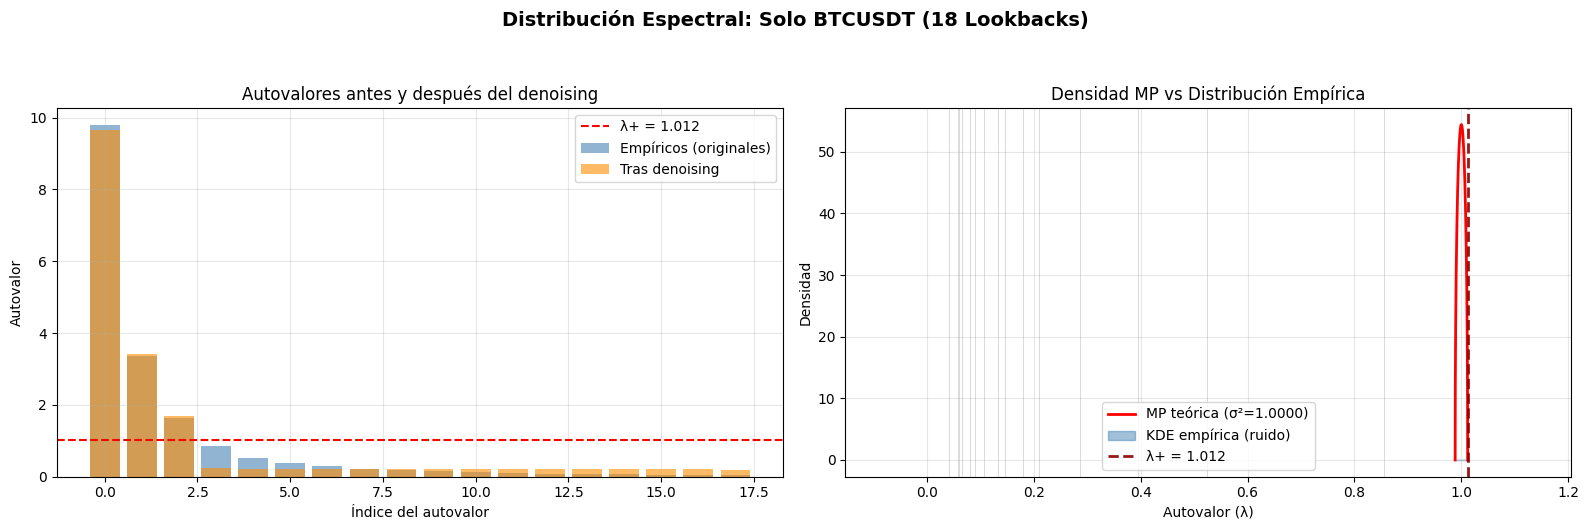

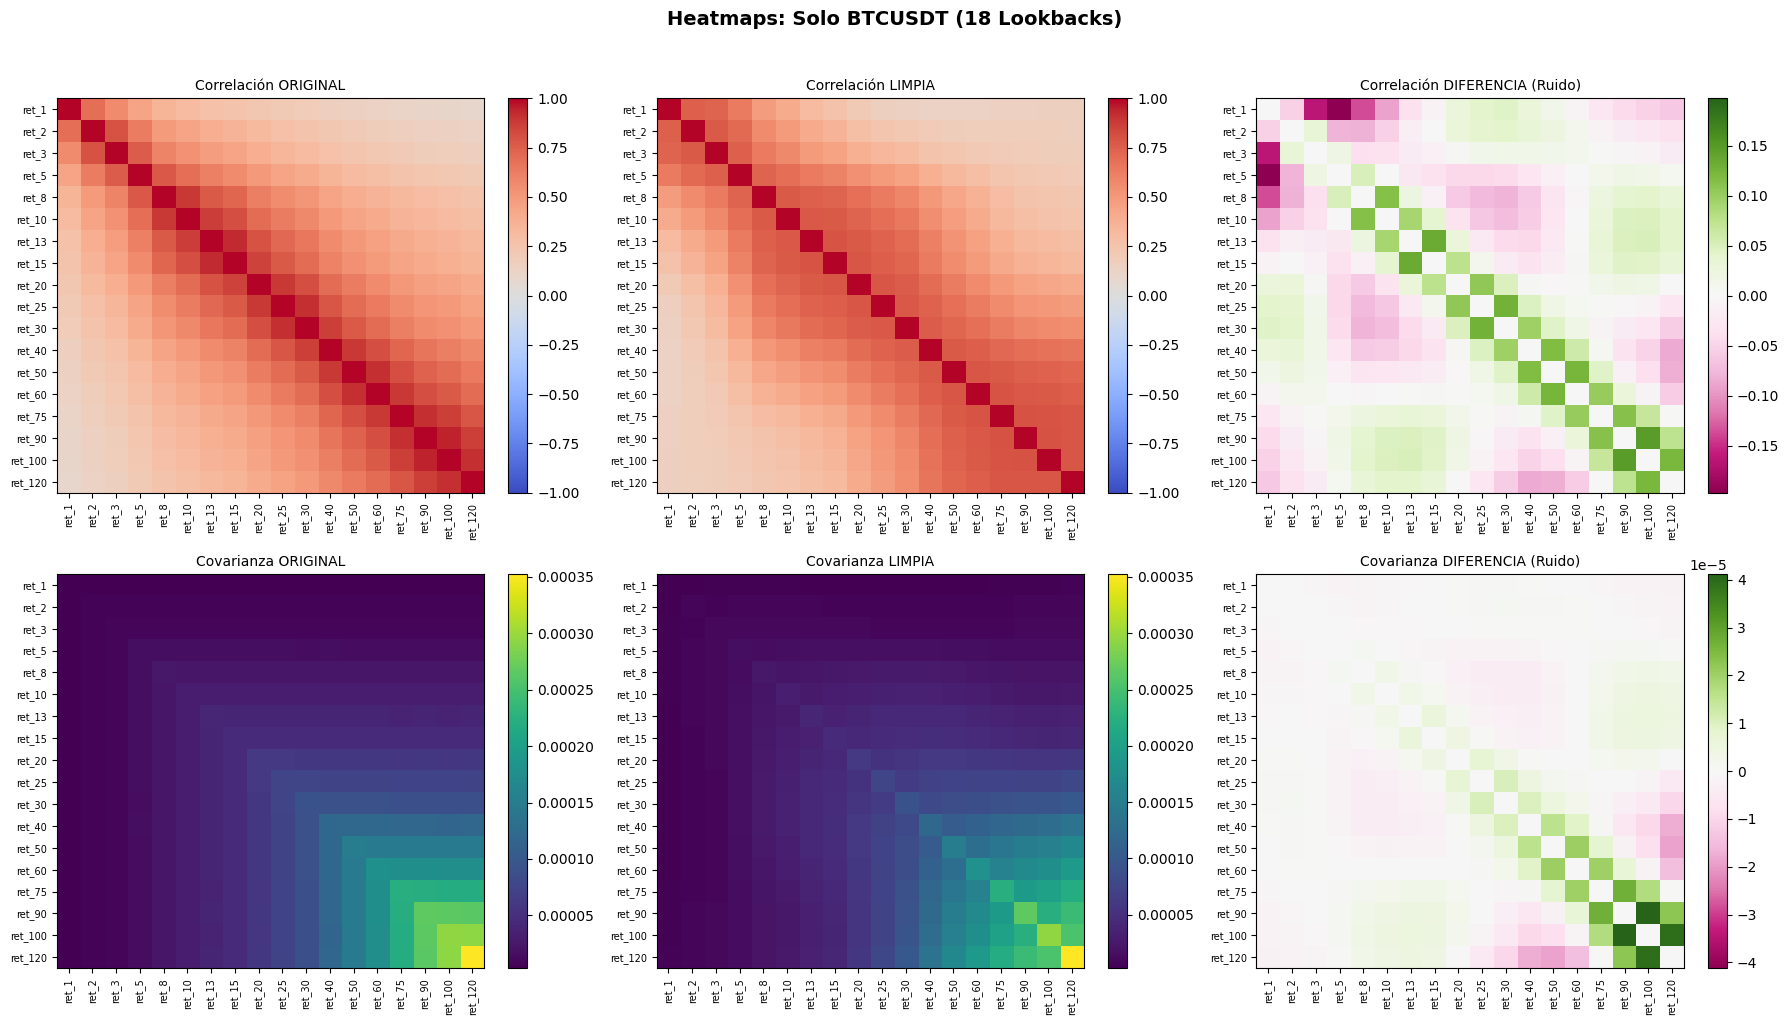

In [94]:
def plot_heatmap_group(returns_df, title_prefix):
    """Calcula Marchenko-Pastur y dibuja todas las gráficas (Autovalores, PDF, Correlación y Covarianza)."""
    T, N = returns_df.shape
    q = T / N
    labels = returns_df.columns
    
    # 1. Cálculos de correlación y limpieza
    corr_emp = returns_df.corr().values
    evals_raw, evecs_raw = np.linalg.eigh(corr_emp)
    idx_sort = np.argsort(evals_raw)[::-1]
    evals_raw, evecs_raw = evals_raw[idx_sort], evecs_raw[:, idx_sort]
    
    var_opt, lambda_max = find_max_eval(evals_raw.reshape(-1, 1), q, bwidth=0.01)
    n_signal = np.sum(evals_raw > lambda_max)
    corr_denoised = denoised_corr(evals_raw, evecs_raw, n_signal)
    
    # Autovalores tras el denoising (para el gráfico de barras)
    evals_den, _ = np.linalg.eigh(corr_denoised)
    evals_den = np.sort(evals_den)[::-1]
    
    # 2. Cálculos de covarianza
    cov_emp = returns_df.cov().values
    std_devs = np.sqrt(np.diag(cov_emp))
    cov_denoised = corr_denoised * np.outer(std_devs, std_devs)
    
    #Gráfico de Autovalores y PDF de Marchenko-Pastur

    fig1, axes1 = plt.subplots(1, 2, figsize=(16, 5))
    fig1.suptitle(f"Distribución Espectral: {title_prefix}", fontsize=14, fontweight="bold", y=1.05)
    
    # Panel izquierdo: autovalores
    ax = axes1[0]
    ax.bar(range(N), evals_raw, alpha=0.6, label="Empíricos (originales)", color="steelblue")
    ax.bar(range(N), evals_den, alpha=0.6, label="Tras denoising", color="darkorange")
    ax.axhline(lambda_max, color="red", linestyle="--", linewidth=1.5, label=f"λ+ = {lambda_max:.3f}")
    ax.set_xlabel("Índice del autovalor")
    ax.set_ylabel("Autovalor")
    ax.set_title("Autovalores antes y después del denoising")
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Panel derecho: función de densidad MP vs empírica (KDE)
    ax = axes1[1]
    x_mp, pdf_mp, _ = mp_pdf(var_opt, q, pts=1000)
    ax.plot(x_mp, pdf_mp, color="red", linewidth=2, label=f"MP teórica (σ²={var_opt:.4f})")
    
    noise_evals = evals_raw[evals_raw <= lambda_max * 1.2]
    if len(noise_evals) > 1:
        x_kde, pdf_kde = fit_kde(noise_evals.reshape(-1, 1), bwidth=0.01, x=x_mp)
        ax.fill_between(x_kde, pdf_kde, alpha=0.5, color="steelblue", label="KDE empírica (ruido)")
        
    for ev in evals_raw:
        if ev <= lambda_max * 1.5:
            ax.axvline(ev, color="gray", alpha=0.4, linewidth=0.5)
        else:
            ax.axvline(ev, color="green", alpha=0.3, linewidth=1.0)
            
    ax.axvline(lambda_max, color="darkred", linestyle="--", alpha=0.9, linewidth=2, label=f"λ+ = {lambda_max:.3f}")
    min_x = min(x_mp.min(), noise_evals.min()) if len(noise_evals) > 0 else x_mp.min()
    padding = (lambda_max - min_x) * 0.2
    ax.set_xlim(min_x - padding, lambda_max + padding)
    ax.set_xlabel("Autovalor (λ)")
    ax.set_ylabel("Densidad")
    ax.set_title("Densidad MP vs Distribución Empírica")
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

    # Heatmaps de Correlación y Covarianza (2x3)
    fig2, axes2 = plt.subplots(2, 3, figsize=(18, 10))
    fig2.suptitle(f"Heatmaps: {title_prefix}", fontsize=14, fontweight="bold", y=1.02)
    
    max_c_diff = np.max(np.abs(corr_emp - corr_denoised))
    max_v_diff = np.max(np.abs(cov_emp - cov_denoised))
    plots = [
        (0, 0, corr_emp, "Correlación ORIGINAL", "coolwarm", -1, 1),
        (0, 1, corr_denoised, "Correlación LIMPIA", "coolwarm", -1, 1),
        (0, 2, corr_emp - corr_denoised, "Correlación DIFERENCIA (Ruido)", "PiYG", -max_c_diff, max_c_diff),
        (1, 0, cov_emp, "Covarianza ORIGINAL", "viridis", None, None),
        (1, 1, cov_denoised, "Covarianza LIMPIA", "viridis", None, None),
        (1, 2, cov_emp - cov_denoised, "Covarianza DIFERENCIA (Ruido)", "PiYG", -max_v_diff, max_v_diff)
    ]
    
    for row, col, matriz, tit, cmap, vmin, vmax in plots:
        ax = axes2[row, col]
        im = ax.imshow(matriz, cmap=cmap, vmin=vmin, vmax=vmax, aspect="auto")
        ax.set_title(tit, fontsize=10)
        ax.set_xticks(range(N)); ax.set_xticklabels(labels, rotation=90, fontsize=7)
        ax.set_yticks(range(N)); ax.set_yticklabels(labels, fontsize=7)
        fig2.colorbar(im, ax=ax, fraction=0.046)
        
    plt.tight_layout()
    plt.show()


#  Solo BTCUSDT - 18 Periodos Granulares

returns_btc = pd.DataFrame()
for lb in [1, 2, 3, 5, 8, 10, 13, 15, 20, 25, 30, 40, 50, 60, 75, 90, 100, 120]:
    returns_btc[f"ret_{lb}"] = dfs["BTCUSDT"]["close"].pct_change(lb)
plot_heatmap_group(returns_btc.dropna(), "Solo BTCUSDT (18 Lookbacks)")

### Distribución espectral y separación del ruido (Marchenko-Pastur)

En las gráficas superiores se visualiza el proceso de limpieza de la matriz de correlación mediante la identificación matemática de sus autovalores correspondientes a pura "señal" vs "ruido de estimación".

**Análisis de los autovalores (Gráfica Izquierda):**
- La línea horizontal roja (`λ+ ≈ 1.008`) marca el umbral límite de la teoría de matrices aleatorias.
- **Señal (Barras Azules/Naranjas idénticas):** Los primeros componentes principales (índices 0 al 3) presentan autovalores significativamente mayores que `λ+`. Estos componentes son deterministas y dictan la estructura verdadera y compartida de la covarianza de los retornos, por lo que el algoritmo los preserva exactamente igual (barras naranjas a la misma altura térmica).
- **Ruido (Barras aplanadas):** Los componentes a partir del índice 4 caen bajo el paraguas estadístico del ruido. Para mitigar los cruces espurios, el *denoising* recorta todos esos autovalores bajos y los aplana matemáticamente sustituyéndolos por su media constante (franja plana naranja), estabilizando drásticamente la matriz.

**Convergencia de la densidad teórica (Gráfica Derecha):**
- La función de densidad de probabilidad teórica de Marchenko-Pastur se traza como una franja extremadamente estrecha e intensa en el entorno del ~1.00. 
- Este fenómeno visual es enteramente esperado dadas las fortísimas propiedades asintóticas del conjunto de datos: al trabajar con alta frecuencia (velas de 5 minutos durante 3 años), el número de observaciones empíricas `T` supera los `315.000`, mientras que dimensionamos `N` (features) apenas en las decenas. Con un ratio `q = T/N` gigantesco, el marco teórico colapsa correctamente en una distribución delta de Dirac muy centrada que absorbe el ruido ínfimo de estimación, un caso óptimo en modelado cuantitativo financiero.

### Observaciones sobre la limpieza de matrices de covarianza (Marchenko-Pastur)

El proceso de *denoising* basado en la distribución teórica de Marchenko-Pastur permite separar matemáticamente la **señal genuina** de la matriz (autovalores por encima de λ+) del **ruido de estimación** (autovalores por debajo de λ+).

**Análisis Univariante Granular (BTCUSDT - 18 Plazos):**
Al aislar el activo y expandir significativamente la granularidad de los plazos temporales (lookbacks de 1 a 120 periodos), la matriz se vuelve grande y propensa al sobreajuste.
- El mapa de **Correlación Original** muestra franjas densas y ligeramente ruidosas entre los distintos periodos de retornos a medio y largo plazo.
- En la matriz de **Diferencia**, se observa un marcado patrón diagonal, indicando que la técnica extrae ruidos sistemáticos muy específicos ligados a la proximidad temporal de las ventanas de cálculo.
- La **Covarianza Limpia** resultante presenta una degradación impecable y suavizada desde el cortísimo plazo hacia el largo plazo, carente de las anomalías presentes en la matriz original empírica.

**Implicación práctica:** 
En modelos de algoritmos de Machine Learning (como clasificación o predicción) y en optimización de carteras, proporcionar como base estas matrices de covarianza y correlación limpias evita que el modelo o el optimizador se sobreajusten a ruidos o anomalías estadísticas aleatorias del pasado, mejorando drásticamente el rendimiento y la estabilidad fuera de muestra.

## 5. Etiquetado Triple Barrera

Este método etiqueta las observaciones de una serie financiera según tres barreras:

1. **Barrera superior (Take Profit):** se activa cuando el retorno acumulado supera un umbral positivo basado en la volatilidad diaria.
2. **Barrera inferior (Stop Loss):** se activa cuando el retorno acumulado cae por debajo de un umbral negativo basado en la volatilidad diaria.
3. **Barrera vertical (temporal):** se activa tras un número máximo de barras sin tocar ninguna de las otras dos barreras.

La etiqueta resultante indica:
- **+1:** se alcanzó primero la barrera de Take Profit/Profit taking (tp/pt).
- **-1:** se alcanzó primero la barrera de Stop Loss(sl).
- **0:** se alcanzó la barrera temporal sin tocar las otras dos, t1 (la etiqueta se asigna según el signo del retorno en ese momento).

Se evalúan múltiples configuraciones de umbrales para analizar cómo el tamaño de las barreras afecta la distribución de etiquetas.

In [95]:
# =============================================================
# Implementación del Triple Barrier Method
# =============================================================

def get_daily_vol(close, span=100):
    """Se calcula la volatilidad diaria como desviación estándar de los retornos
    con una media móvil exponencial (EWM)."""
    ret = close.pct_change()
    vol = ret.ewm(span=span).std()
    return vol


def get_events(close, t_events, pt_sl, vol, min_ret=1e-5, num_bars=50):
    """Se generan los eventos con las tres barreras.
    - close: serie de precios de cierre.
    - t_events: índices de los eventos a etiquetar.
    - pt_sl: lista [pt_factor, sl_factor] con multiplicadores de volatilidad.
    - vol: serie de volatilidad.
    - min_ret: retorno mínimo para considerar la barrera.
    - num_bars: número máximo de barras para la barrera vertical.
    """
    barriers = pd.DataFrame(index=t_events, columns=["t1", "pt", "sl"])
    close_vals = close.values
    n = len(close_vals)

    for i in t_events:
        if i >= n or i < 0:
            continue
        target = max(vol.iloc[i], min_ret)
        pt_level = target * pt_sl[0] if pt_sl[0] > 0 else np.nan
        sl_level = -target * pt_sl[1] if pt_sl[1] > 0 else np.nan

        t1 = min(i + num_bars, n - 1)
        pt_touch = np.nan
        sl_touch = np.nan

        for j in range(i + 1, t1 + 1):
            if j >= n:
                break
            ret = close_vals[j] / close_vals[i] - 1
            if not np.isnan(pt_level) and ret >= pt_level:
                pt_touch = j
                break
            if not np.isnan(sl_level) and ret <= sl_level:
                sl_touch = j
                break

        barriers.loc[i, "t1"] = t1
        barriers.loc[i, "pt"] = pt_touch
        barriers.loc[i, "sl"] = sl_touch

    return barriers.dropna(subset=["t1"])


def get_bins(barriers, close):
    """Se asignan las etiquetas basándose en las barreras calculadas."""
    close_vals = close.values
    n = len(close_vals)
    locs = barriers.index.values
    t1_vals = barriers["t1"].values.astype(int)
    pt_vals = barriers["pt"].values.astype(float)
    sl_vals = barriers["sl"].values.astype(float)

    labels = np.zeros(len(barriers), dtype=int)
    rets = np.zeros(len(barriers), dtype=float)

    for i in range(len(barriers)):
        loc = locs[i]
        t1 = min(t1_vals[i], n - 1)
        has_pt = not np.isnan(pt_vals[i])
        has_sl = not np.isnan(sl_vals[i])

        if has_sl and has_pt:
            if sl_vals[i] <= pt_vals[i]:
                label = -1
                first_touch = int(sl_vals[i])
            else:
                label = 1
                first_touch = int(pt_vals[i])
        elif has_sl:
            label = -1
            first_touch = int(sl_vals[i])
        elif has_pt:
            label = 1
            first_touch = int(pt_vals[i])
        else:
            ret_at_t1 = close_vals[t1] / close_vals[loc] - 1 if t1 < n else 0
            label = label = 0
            first_touch = t1

        first_touch = min(first_touch, n - 1)
        labels[i] = label
        rets[i] = close_vals[first_touch] / close_vals[loc] - 1

    return pd.DataFrame({"t1": t1_vals, "label": labels, "ret": rets}, index=barriers.index)


close_bars = df_bars["close"].reset_index(drop=True)
vol = get_daily_vol(close_bars, span=100)

# Se define el conjunto de eventos (a partir de la barra 100 para tener volatilidad estimada)
t_events = pd.Index(range(100, len(close_bars) - 50))

# Tres configuraciones de [pt, sl] y tres ventanas verticales
pt_sl_configs = [
    ([1, 1], "profit taking =1, stop loss =1 (normal)"),
    ([3, 3], "profit taking =3, stop loss=3 (muy amplio)"),     
    ([0.5, 0.5], "profit taking =0.5, stop loss=0.5 (estrecho)")
]
vertical_windows = [3, 15, 50]    

print(f"Total barras: {len(close_bars):,}")
print(f"Eventos a evaluar: {len(t_events):,}")
print(f"Configuraciones: {len(pt_sl_configs)} x {len(vertical_windows)} ventanas = "
      f"{len(pt_sl_configs) * len(vertical_windows)} combinaciones")

# Se calculan todas las combinaciones
all_results = {}
for (pt_sl, config_name) in pt_sl_configs:
    for vw in vertical_windows:
        key = f"{config_name}\nV={vw} barras"
        print(f"  Procesando: {config_name}, V={vw}...", end=" ")
        barriers = get_events(close_bars, t_events, pt_sl, vol, min_ret=1e-5, num_bars=vw)
        bins = get_bins(barriers, close_bars)
        all_results[key] = bins
        counts = bins["label"].value_counts().sort_index()
        print(f"-> {len(bins)} eventos etiquetados: {dict(counts)}")


Total barras: 14,438
Eventos a evaluar: 14,288
Configuraciones: 3 x 3 ventanas = 9 combinaciones
  Procesando: profit taking =1, stop loss =1 (normal), V=3... -> 14288 eventos etiquetados: {-1: np.int64(4605), 0: np.int64(4843), 1: np.int64(4840)}
  Procesando: profit taking =1, stop loss =1 (normal), V=15... -> 14288 eventos etiquetados: {-1: np.int64(7009), 0: np.int64(111), 1: np.int64(7168)}
  Procesando: profit taking =1, stop loss =1 (normal), V=50... -> 14288 eventos etiquetados: {-1: np.int64(7082), 1: np.int64(7206)}
  Procesando: profit taking =3, stop loss=3 (muy amplio), V=3... -> 14288 eventos etiquetados: {-1: np.int64(706), 0: np.int64(12849), 1: np.int64(733)}
  Procesando: profit taking =3, stop loss=3 (muy amplio), V=15... -> 14288 eventos etiquetados: {-1: np.int64(4557), 0: np.int64(5067), 1: np.int64(4664)}
  Procesando: profit taking =3, stop loss=3 (muy amplio), V=50... -> 14288 eventos etiquetados: {-1: np.int64(6877), 0: np.int64(532), 1: np.int64(6879)}
  Proc

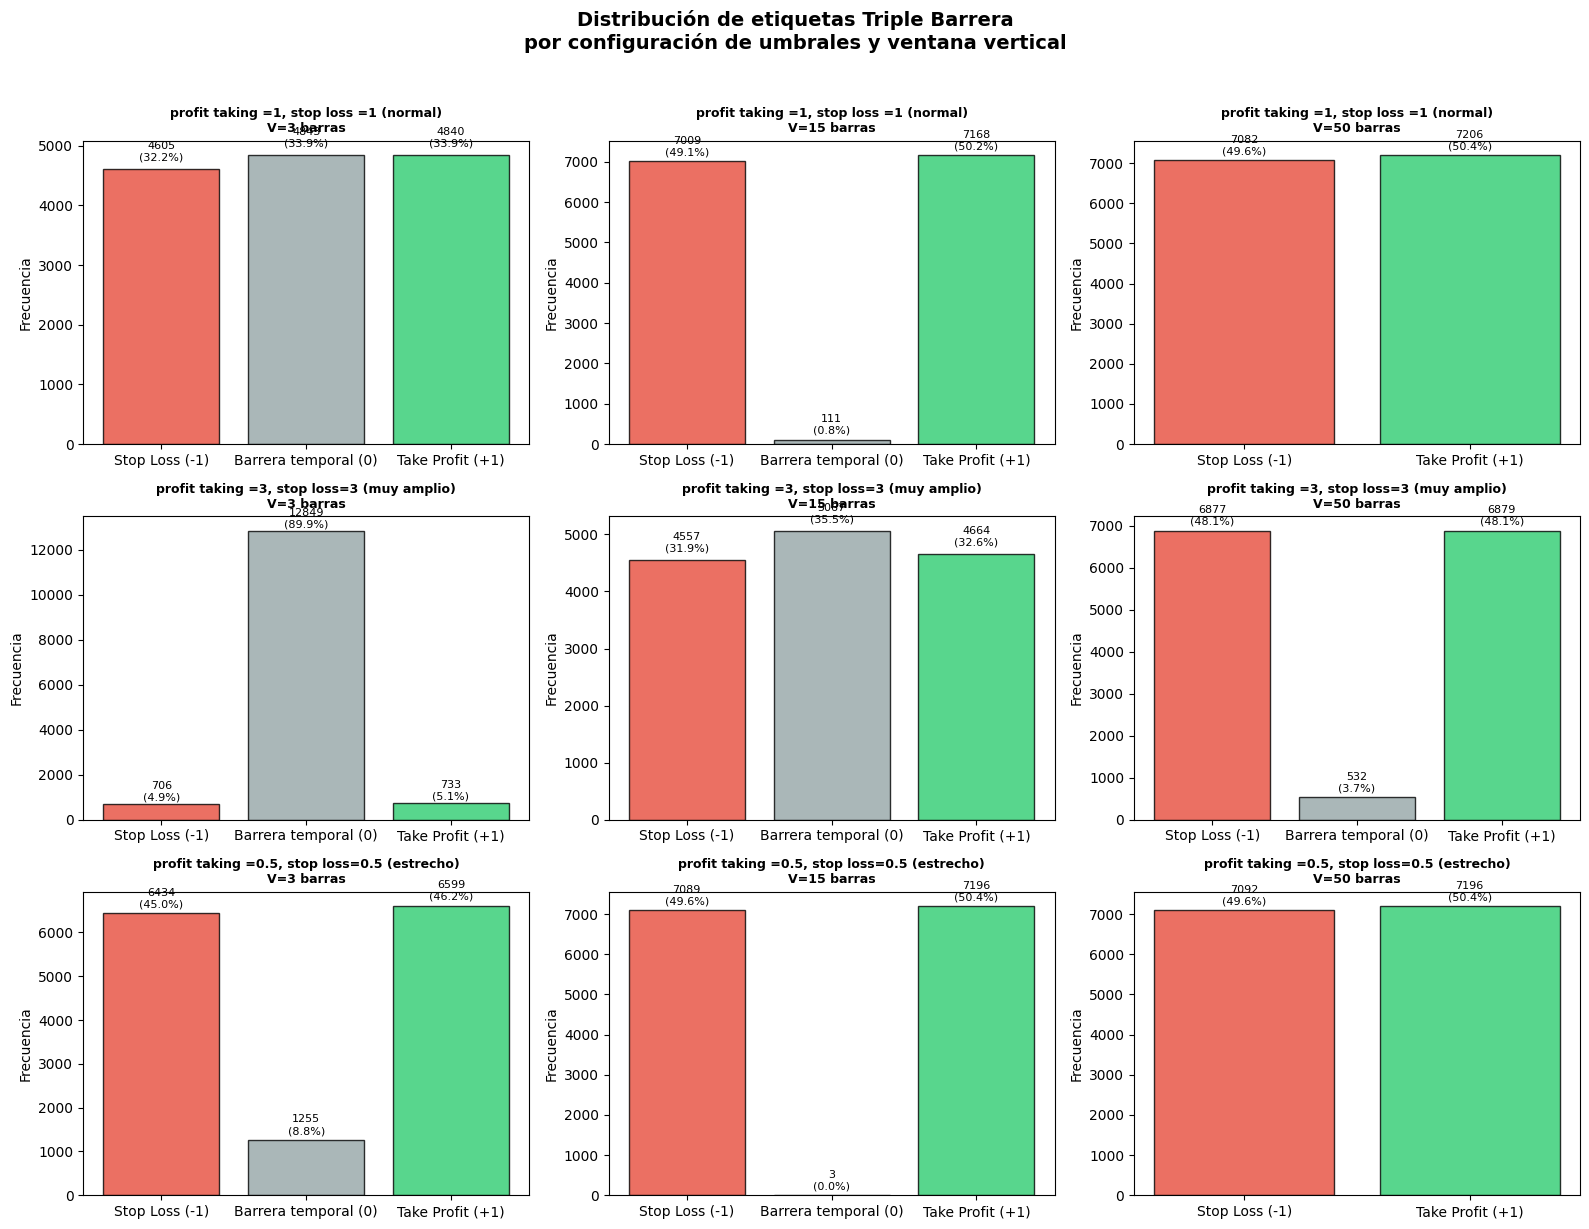

In [96]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))

keys = list(all_results.keys())
colors_map = {-1: "#e74c3c", 0: "#95a5a6", 1: "#2ecc71"}
label_names = {-1: "Stop Loss (-1)", 0: "Barrera temporal (0)", 1: "Take Profit (+1)"}

for idx, key in enumerate(keys):
    row = idx // 3
    col = idx % 3
    ax = axes[row, col]
    bins = all_results[key]
    counts = bins["label"].value_counts().sort_index()

    bar_colors = [colors_map.get(k, "gray") for k in counts.index]
    bar_labels = [label_names.get(k, str(k)) for k in counts.index]

    ax.bar(bar_labels, counts.values, color=bar_colors, alpha=0.8, edgecolor="black")
    ax.set_title(key, fontsize=9, fontweight="bold")
    ax.set_ylabel("Frecuencia")

    total = counts.sum()
    for i, (lab, val) in enumerate(zip(bar_labels, counts.values)):
        ax.text(i, val + total * 0.01, f"{val}\n({val/total:.1%})",
                ha="center", fontsize=8)

plt.suptitle("Distribución de etiquetas Triple Barrera\npor configuración de umbrales y ventana vertical",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


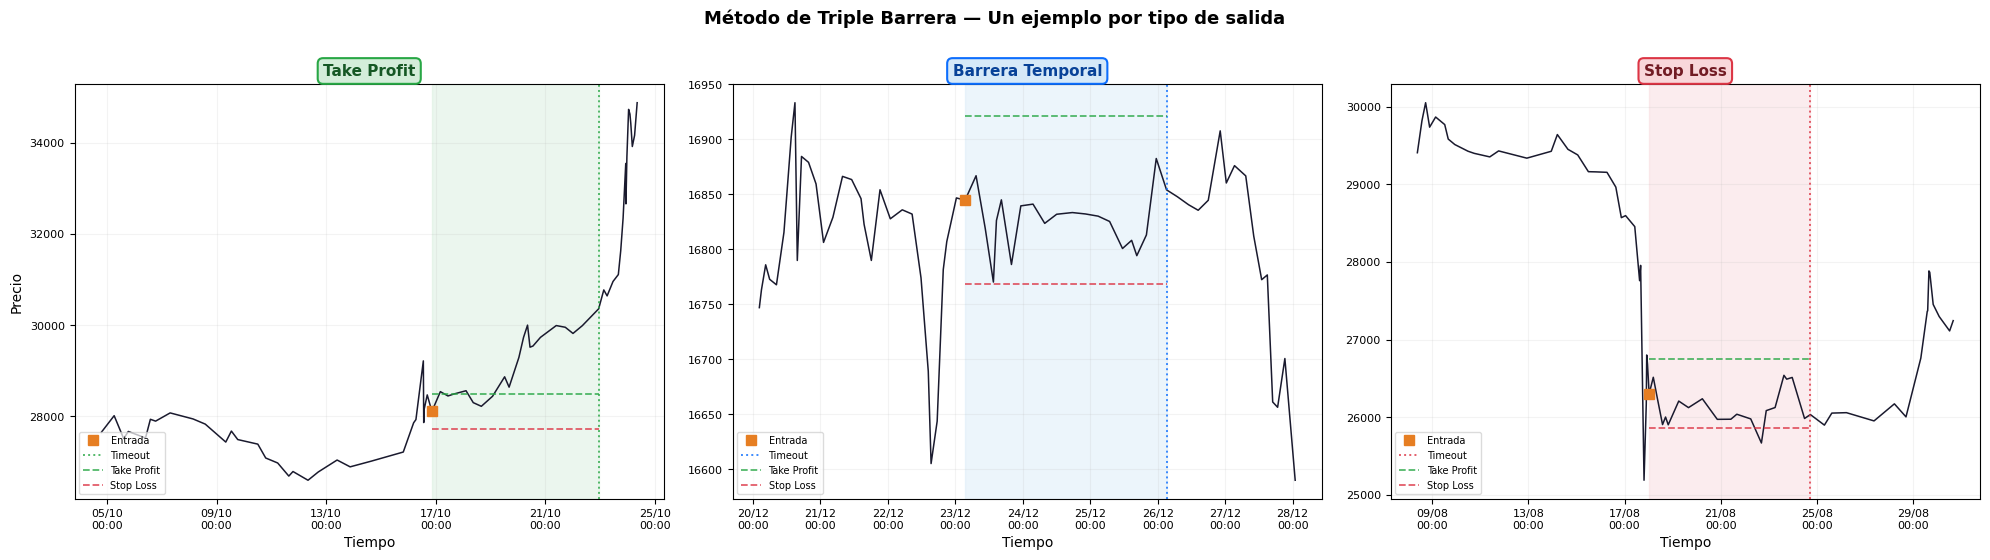

In [97]:
# --- Ejemplos representativos: Triple Barrera (TP, SL, Timeout) ---
import matplotlib.dates as mdates
import matplotlib.patches as mpatches

# Recomputar barreras para visualización
pt_sl_vis = [1, 1]
num_bars_vis = 20
vol_vis = get_daily_vol(close_bars, span=100)
t_events_vis = pd.Index(range(100, len(close_bars) - num_bars_vis))
barriers_vis = get_events(close_bars, t_events_vis, pt_sl_vis, vol_vis, min_ret=1e-5, num_bars=num_bars_vis)
bins_vis = get_bins(barriers_vis, close_bars)

# Buscar un ejemplo de cada tipo de salida
example_events = {}
for target_label, name in [(1, "Take Profit"), (-1, "Stop Loss"), (0, "Barrera Temporal")]:
    candidates = bins_vis[bins_vis["label"] == target_label].index.tolist()
    if candidates:
        np.random.seed(7)
        example_events[target_label] = np.random.choice(candidates)

has_time = "open_time" in df_bars.columns
if has_time:
    timestamps = df_bars["open_time"].reset_index(drop=True)

# Paleta y estilos diferenciados
style_map = {
    1:  {"title": "Take Profit",     "bg": "#d4edda", "border": "#28a745", "text_col": "#155724", "price_col": "#1a1a2e"},
    -1: {"title": "Stop Loss",       "bg": "#f8d7da", "border": "#dc3545", "text_col": "#721c24", "price_col": "#1a1a2e"},
    0:  {"title": "Barrera Temporal", "bg": "#d6e9f8", "border": "#0d6efd", "text_col": "#084298", "price_col": "#1a1a2e"},
}

fig, axes = plt.subplots(1, 3, figsize=(20, 5.5), sharey=False)
fig.suptitle("Método de Triple Barrera — Un ejemplo por tipo de salida",
             fontsize=13, fontweight="bold", y=1.01)

for ax, (label, event_idx) in zip(axes, sorted(example_events.items(), key=lambda x: -x[0])):
    sty = style_map[label]
    loc = event_idx
    t1 = int(barriers_vis.loc[loc, "t1"])
    entry_price = close_bars.iloc[loc]
    target = max(vol_vis.iloc[loc], 1e-5)
    pt_price = entry_price * (1 + target * pt_sl_vis[0])
    sl_price = entry_price * (1 - target * pt_sl_vis[1])

    # Rango: 30 barras antes, 15 después del cierre
    start = max(0, loc - 30)
    end = min(t1 + 15, len(close_bars) - 1)
    plot_range = range(start, end + 1)
    prices = close_bars.iloc[plot_range]

    if has_time:
        x_vals = timestamps.iloc[plot_range]
        x_entry = timestamps.iloc[loc]
        x_t1 = timestamps.iloc[t1]
    else:
        x_vals = list(plot_range)
        x_entry = loc
        x_t1 = t1

    # Sombrear zona activa entre entrada y t1
    ax.axvspan(x_entry, x_t1, color=sty["bg"], alpha=0.45, zorder=0)

    # Línea de precio
    ax.plot(x_vals, prices.values, color=sty["price_col"], linewidth=1.1, zorder=2)

    # Punto de entrada
    ax.plot(x_entry, entry_price, 's', color="#e67e22", markersize=7, zorder=5, label="Entrada")

    # Barrera temporal
    ax.axvline(x_t1, color=sty["border"], linestyle=":", linewidth=1.4, alpha=0.8, label="Timeout")

    # Barreras horizontales TP / SL
    h_x0 = x_entry
    h_x1 = x_t1
    ax.hlines(pt_price, h_x0, h_x1, colors="#28a745", linestyles="--", linewidth=1.3, alpha=0.8, label="Take Profit")
    ax.hlines(sl_price, h_x0, h_x1, colors="#dc3545", linestyles="--", linewidth=1.3, alpha=0.8, label="Stop Loss")

    # Etiqueta resultado
    ax.set_title(f"{sty['title']}", fontsize=11, fontweight="bold", color=sty["text_col"],
                 bbox=dict(boxstyle="round,pad=0.35", facecolor=sty["bg"], edgecolor=sty["border"], linewidth=1.5))

    ax.legend(fontsize=7, loc="lower left", framealpha=0.7)
    ax.set_ylabel("Precio" if ax == axes[0] else "")
    ax.set_xlabel("Tiempo")
    ax.grid(True, alpha=0.15, linestyle="-")
    ax.tick_params(axis='both', labelsize=8)
    if has_time:
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m\n%H:%M'))
        ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

### Observaciones sobre el etiquetado Triple Barrera (Triple Barrier Method)

Se analizan las distribuciones de las tres etiquetas (`-1` Stop Loss, `1` Take Profit, y `0` Expiración Temporal) obtenidas al cruzar distintas exigencias de volatilidad con distintos límites de tiempo (ventana V).

**1. Efecto de la exigencia del precio (umbrales pt y sl):**
- **Umbrales bajos (pt=0.5, sl=0.5):** Al pedirle al precio un movimiento direccional muy pequeño (media desviación), las barreras horizontales se alcanzan casi de inmediato. Esto provoca que el reloj prácticamente nunca llegue a cero (la clase temporal `0` desaparece).
- **Umbrales extremos (pt=3, sl=3):** Al exigir un movimiento enorme (tres desviaciones), el precio es matemáticamente incapaz de alcanzar la meta antes de que se agote el tiempo, provocando que la inmensa mayoría de las operaciones expiren y se etiqueten como clase `0` (ver panel intermedio izquierdo).

**2. Efecto del límite temporal (Ventana Vertical V):**
- **Ventanas muy cortas (V=3):** Fuerzan al precio a hacer movimientos bruscos en apenas 15 minutos. Como esto es raro, la barrera temporal "corta" la operación prematuramente y dispara masivamente la etiqueta `0`.
- **Ventanas largas (V=50):** Dan al precio más de 4 horas para oscilar libremente. En un activo hiper-volátil como BTC, este tiempo es más que suficiente para acabar cruzando la volatilidad estándar de 1 o 2 desviaciones en cualquier dirección, reduciendo la clase temporal a cero.

**Implicación práctica:** 
En los modelos de Machine Learning Financiero, el etiquetado no debe ser estático ni elegido al azar. Hemos demostrado empíricamente cómo el riesgo paramétrico de la temporalidad reduce drásticamente las oportunidades de TP/SL. Para entrenar un modelo que aprenda cuándo operar y cuándo quedarse quieto (clase `0`), la parametrización ideal en criptomonedas requiere estrechar agresivamente la ventana vertical temporal frente a la amplitud de la volatilidad esperada.


## 6. Validación cruzada Purged K-Fold

Se implementa la técnica de **Purged K-Fold Cross-Validation** . En datos financieros, la validación cruzada estándar (K-Fold) puede producir *data leakage* debido a la dependencia temporal entre observaciones:

- Las observaciones del conjunto de entrenamiento que están temporalmente cerca del conjunto de test pueden contener información que se solapa con las del test.
- Este solapamiento infla artificialmente las métricas de rendimiento del modelo.

### Solución: Purging y Embargo

1. **Purging:** Se eliminan del conjunto de entrenamiento las observaciones cuyo período de validez se solapa con alguna observación del conjunto de test.
2. **Embargo:** Se añade un margen de seguridad adicional eliminando observaciones del entrenamiento inmediatamente posteriores al conjunto de test, para prevenir la filtración por efectos rezagados.

Se compara visualmente la partición estándar K-Fold con la Purged K-Fold, mostrando las zonas de entrenamiento, test y purgado/embargo.

In [98]:
# Purged K-Fold CV
from sklearn.model_selection import KFold

class PurgedKFold:
    """Implementación de Purged K-Fold Cross-Validation con embargo."""
    def __init__(self, n_splits=5, t1=None, pct_embargo=0.0):
        self.n_splits = n_splits
        self.t1 = t1          # Serie con el índice de fin del evento para cada observación
        self.pct_embargo = pct_embargo

    def split(self, X):
        """Se generan los índices de train/test con purging y embargo."""
        n = len(X)
        indices = np.arange(n)
        embargo = int(n * self.pct_embargo)

        # Se divide en K folds contiguos
        fold_size = n // self.n_splits
        folds = []
        for i in range(self.n_splits):
            start = i * fold_size
            end = start + fold_size if i < self.n_splits - 1 else n
            folds.append(indices[start:end])

        for i in range(self.n_splits):
            test_idx = folds[i]
            test_start = test_idx[0]
            test_end = test_idx[-1]

            train_idx = []
            for j in indices:
                if j in test_idx:
                    continue
                # si el evento j tiene un t1 que cae dentro del rango del test
                if self.t1 is not None:
                    t1_j = int(self.t1.iloc[j]) if j < len(self.t1) else j
                    if t1_j >= test_start and j < test_start:
                        continue
                #  si la observación está en la zona de embargo tras el test
                if embargo > 0 and j > test_end and j <= test_end + embargo:
                    continue
                train_idx.append(j)

            yield np.array(train_idx), test_idx


def _contiguous_ranges(arr):
    """Se identifican rangos contiguos en un array de índices."""
    if len(arr) == 0:
        return
    start = arr[0]
    end = arr[0]
    for v in arr[1:]:
        if v == end + 1:
            end = v
        else:
            yield start, end + 1
            start = v
            end = v
    yield start, end + 1



first_key = list(all_results.keys())[0]
sample_bins = all_results[first_key]
t1_series = sample_bins["t1"]
n_vis = min(len(sample_bins), 2000)  # Se limita para visualización
X_vals = np.arange(n_vis)

print(f"Se utilizan {n_vis} observaciones para la demostración visual de Purged K-Fold.")
print(f"Datos del etiquetado Triple Barrera (config: {first_key.split(chr(10))[0]})")


Se utilizan 2000 observaciones para la demostración visual de Purged K-Fold.
Datos del etiquetado Triple Barrera (config: profit taking =1, stop loss =1 (normal))


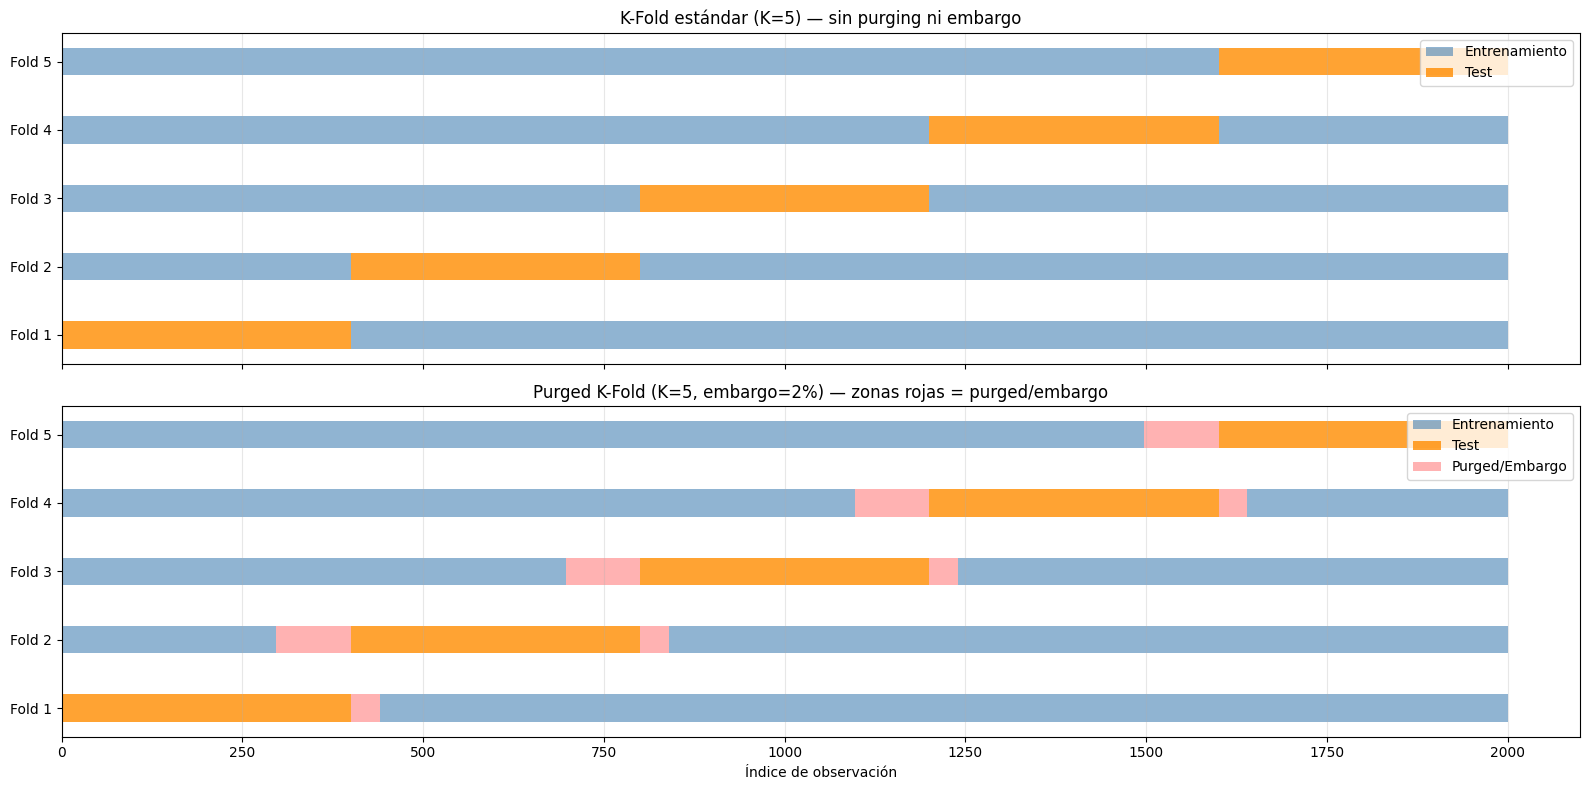

In [99]:
# comparación K-Fold estándar vs Purged K-Fold
from matplotlib.patches import Patch

k_vis = 5

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

#  Panel 1: K-Fold estándar 
ax = axes[0]
kf = KFold(n_splits=k_vis, shuffle=False)
for fold_i, (train_idx, test_idx) in enumerate(kf.split(X_vals)):
    for start, end in _contiguous_ranges(train_idx):
        ax.barh(fold_i, end - start, left=start, height=0.4, color="steelblue", alpha=0.6)
    ax.barh(fold_i, len(test_idx), left=test_idx[0], height=0.4, color="darkorange", alpha=0.8)

ax.set_yticks(range(k_vis))
ax.set_yticklabels([f"Fold {i+1}" for i in range(k_vis)])
ax.set_title(f"K-Fold estándar (K={k_vis}) — sin purging ni embargo", fontsize=12)
legend_elements = [Patch(facecolor="steelblue", alpha=0.6, label="Entrenamiento"),
                   Patch(facecolor="darkorange", alpha=0.8, label="Test")]
ax.legend(handles=legend_elements, loc="upper right")
ax.grid(True, axis="x", alpha=0.3)

#  Panel 2: Purged K-Fold con embargo 
ax = axes[1]
pct_emb_vis = 0.02
pkf = PurgedKFold(n_splits=k_vis, t1=t1_series, pct_embargo=pct_emb_vis)

for fold_i, (train_idx, test_idx) in enumerate(pkf.split(X_vals)):
    for start, end in _contiguous_ranges(train_idx):
        ax.barh(fold_i, end - start, left=start, height=0.4, color="steelblue", alpha=0.6)
    ax.barh(fold_i, len(test_idx), left=test_idx[0], height=0.4, color="darkorange", alpha=0.8)
    # Se colorean las zonas purgadas/embargadas
    all_used = set(train_idx) | set(test_idx)
    purged = sorted(set(range(n_vis)) - all_used)
    for start, end in _contiguous_ranges(np.array(purged)):
        ax.barh(fold_i, end - start, left=start, height=0.4, color="red", alpha=0.3)

ax.set_yticks(range(k_vis))
ax.set_yticklabels([f"Fold {i+1}" for i in range(k_vis)])
ax.set_xlabel("Índice de observación")
ax.set_title(f"Purged K-Fold (K={k_vis}, embargo={pct_emb_vis:.0%}) — zonas rojas = purged/embargo", fontsize=12)
legend_elements2 = [Patch(facecolor="steelblue", alpha=0.6, label="Entrenamiento"),
                    Patch(facecolor="darkorange", alpha=0.8, label="Test"),
                    Patch(facecolor="red", alpha=0.3, label="Purged/Embargo")]
ax.legend(handles=legend_elements2, loc="upper right")
ax.grid(True, axis="x", alpha=0.3)

plt.tight_layout()
plt.show()


### Observaciones sobre la Validación Cruzada: Purging y Embargo (López de Prado)

La evaluación de modelos de Machine Learning (ML) en series temporales financieras requiere técnicas especializadas para evitar la filtración de información futura (*Data Leakage*), un problema derivado de la fuerte autocorrelación de los precios y de la resolución diferida de las etiquetas.

**K-Fold estándar vs Purged K-Fold:**
- El **K-Fold estándar (Gráfico Superior)** asume que las observaciones son independientes (IID). Al aplicar el Triple Barrier Method, la etiqueta del instante $t$ se decide analizando el futuro hasta el instante $t+V$. Si el conjunto de Test en K-Fold comienza justo en $t+1$, el modelo de Entrenamiento dispondrá de información que cronológicamente pertenece al Test, inflando artificialmente las métricas de evaluación.
- El **Purged K-Fold (Gráfico Inferior)** soluciona este solapamiento mediante la técnica de "Purga" (zonas rosas). El algoritmo extirpa físicamente del Training Set todas las filas cuyo horizonte temporal de resolución (la barrera vertical $V$) se introduzca o pise el límite temporal del conjunto de Test. De esta forma, garantiza un examen en un entorno 100% virgen (Out-of-Sample real).

**Efecto del Embargo:**
- El Purging limpia el solapamiento directo, pero el **Embargo** añade un escudo adicional *después* del bloque de Test. Al imponer un Embargo (ej. 2-5%), eliminamos las observaciones de Entrenamiento inmediatamente posteriores al Test, previniendo que el modelo deduzca lo ocurrido en el Test a partir de los "ecos" estadísticos o retornos rezagados (*lagged effects*).

**Efecto de K:**
- Un número elevado de divisiones ($K$ grande) reduce la varianza de la evaluación y genera bloques de Test más pequeños. Sin embargo, en series temporales de alta resolución, obliga a ejecutar el proceso de Purging y Embargo en demasiadas fronteras, destruyendo un porcentaje masivo de datos de entrenamiento valiosos (barras rosas devorando las barras azules). Es necesario equilibrar la robustez estadística con la preservación del volumen de datos históricos.

**Implicación Práctica en Algorithmic Trading:** 
Al combinar el etiquetado por Triple Barrera con el fraccionamiento Purged K-Fold, aseguramos que el entrenamiento del modelo de ML sea extremadamente conservador, realista y matemáticamente aislado. Un modelo que consiga precisión predictiva bajo este estricto régimen de pruebas tiene métricas fiables y mayores probabilidades de sobrevivir íntegro en la transición a operativa *Live Trading*.
